In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import math
import scipy.stats
import warnings
from scipy.stats import norm

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler

seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# GPU 사용 시
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# PyTorch 연산을 최대한 deterministic하게 설정
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 가능하면 deterministic algorithm 사용
torch.use_deterministic_algorithms(True)


# ==================================================
# Anomaly Transformer 정의
# ==================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class AnomalyAttention(nn.Module):
    def __init__(self, d_model, num_heads, sigma=1.0):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.sigma = sigma

    def forward(self, x):
        B, T, D = x.size()

        Q = self.q_linear(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.k_linear(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.v_linear(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        series_attn = F.softmax(scores, dim=-1)

        pos = torch.arange(T, device=x.device).unsqueeze(0)
        gaussian = torch.exp(-((pos.T - pos) ** 2) / (self.sigma ** 2))
        prior_attn = gaussian / gaussian.sum(dim=-1, keepdim=True)
        prior_attn = prior_attn.unsqueeze(0).unsqueeze(0).expand(B, self.num_heads, T, T)

        log_series_attn = (series_attn + 1e-8).log()
        dis_loss = F.kl_div(log_series_attn, prior_attn, reduction='batchmean')

        context = torch.matmul(series_attn, V)
        context = context.transpose(1, 2).contiguous().view(B, T, D)

        output = self.out_proj(context)

        return output, dis_loss


class AnomalyTransformer(nn.Module):
    def __init__(self, input_dim=2, d_model=128, num_heads=8, sigma=1.0):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.anomaly_attn = AnomalyAttention(d_model, num_heads, sigma)
        self.output_proj = nn.Linear(d_model, input_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        encoded, dis_loss = self.anomaly_attn(x)
        out = self.output_proj(encoded)

        return out, dis_loss


# ==================================================
# 8주 window 생성 함수
# ==================================================
def make_windows(data, window_size=8):
    windows = []

    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i + window_size])

    return np.array(windows, dtype=np.float32)


# ==================================================
# 모델 학습 함수
# ==================================================
def train_anomaly_transformer(model, train_windows, epochs=100, lr=0.001, lambda_dis=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_tensor = torch.tensor(train_windows, dtype=torch.float32)

    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        output_tensor, dis_loss = model(train_tensor)

        recon_loss = criterion(output_tensor, train_tensor)

        loss = recon_loss + lambda_dis * dis_loss

        loss.backward()
        optimizer.step()

    return model


# ==================================================
# 데이터 불러오기
# ==================================================
original = pd.read_csv('c:\\python\\data2(filtered).csv', dtype={2: 'str'}).iloc[:, 2:7]

original = original.reset_index(drop=True)

# 신고중량이 0인 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])

original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week

original['연도주차'] = original['연도'] * 100 + original['주차']

original.loc[(original['월'] == 1) & (original['주차'] > 5), '연도주차'] -= 100
original.loc[(original['월'] == 12) & (original['주차'] < 5), '연도주차'] += 100

original['연도주차'] = original['연도주차'].apply(
    lambda x: str(x)[2:4] + '_' + str(x)[4:]
)

date_index = original['연도주차'].unique()

use_col = [
    'HS10단위부호',
    '연도주차',
    '무역거래처국가코드',
    '신고중량',
    '과세가격미화금액'
]

p_eriod = -52


HS Code : 3102109000
      연도주차    단가         신고중량
0    17_03 0.252  4863455.150
1    17_04 0.255  5332959.546
2    17_05 0.262  6013912.829
3    17_06 0.266  5785572.955
4    17_07 0.274  6293268.930
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]


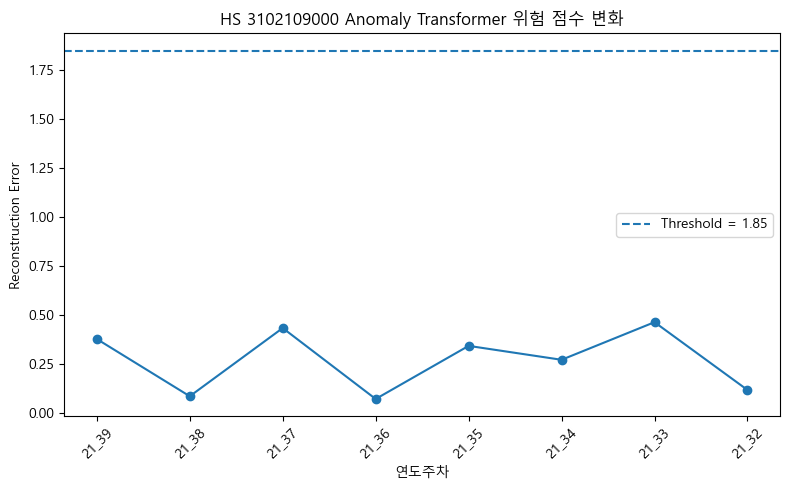

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_03 201.260 13493.463
1    17_04 219.044 17693.709
2    17_05 213.153 21010.400
3    17_06 216.113 19536.734
4    17_07 227.025 18619.221
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]


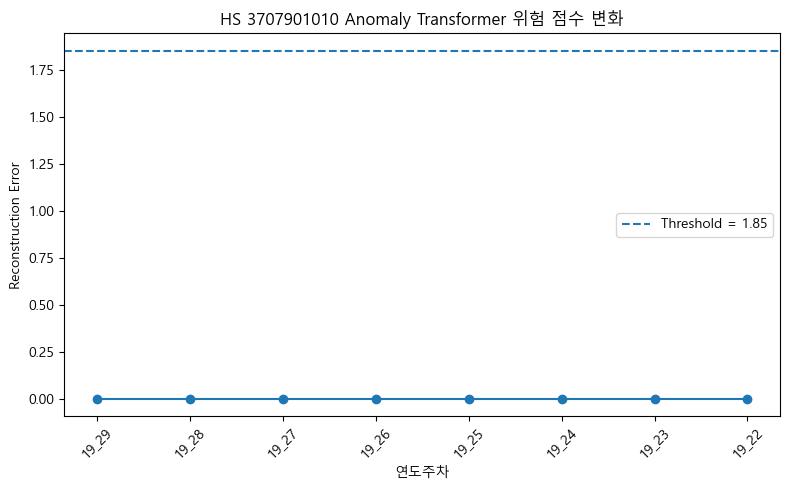

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_03 1.314 181711.497
1    17_04 1.321 239293.247
2    17_05 1.320 250460.747
3    17_06 1.335 267243.948
4    17_07 1.353 205743.000
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]


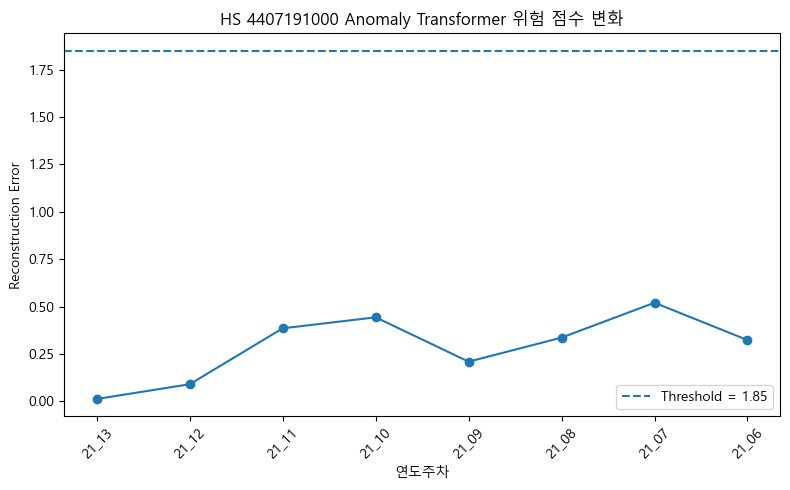

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_03 2.313 1187913.647
1    17_04 2.294 1589538.823
2    17_05 2.322 1797062.025
3    17_06 2.349 2135029.125
4    17_07 2.255 2589847.688
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]


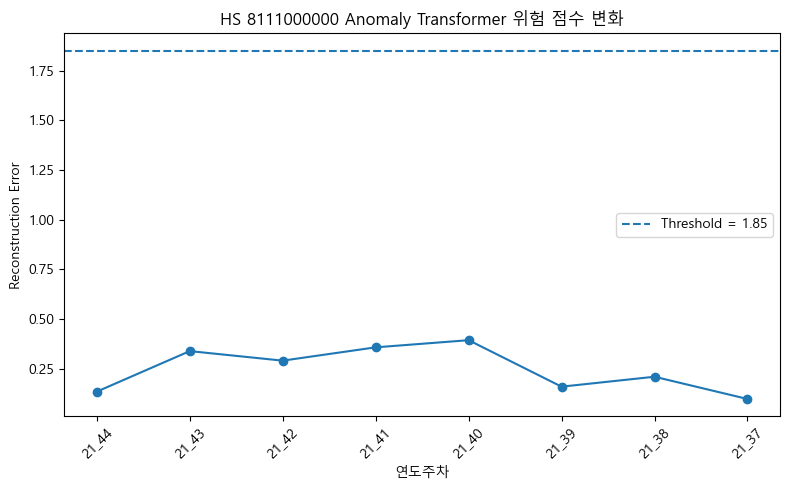

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_03 0.178 143718782.500
1    17_04 0.177 163414532.500
2    17_05 0.183 128339537.000
3    17_06 0.187  77542167.000
4    17_07 0.178  87019096.075
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]


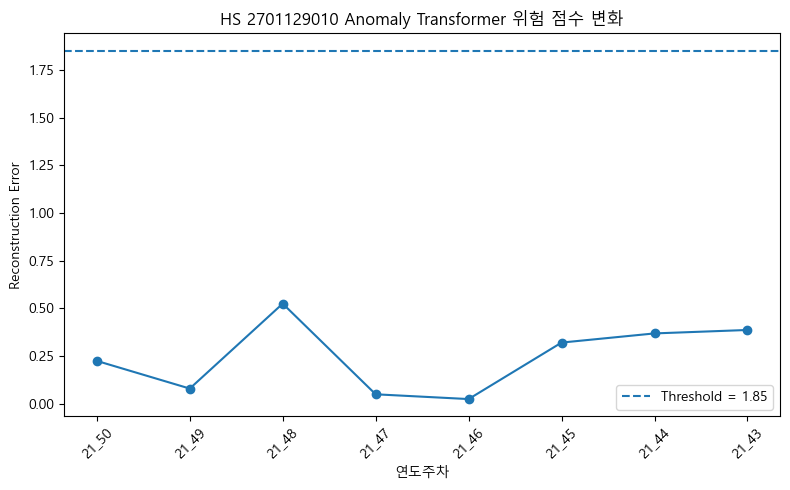

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_03 2.772 123365.050
1    17_04 2.811 160032.550
2    17_05 2.856 164322.550
3    17_06 2.862 142277.500
4    17_07 2.849 143690.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]


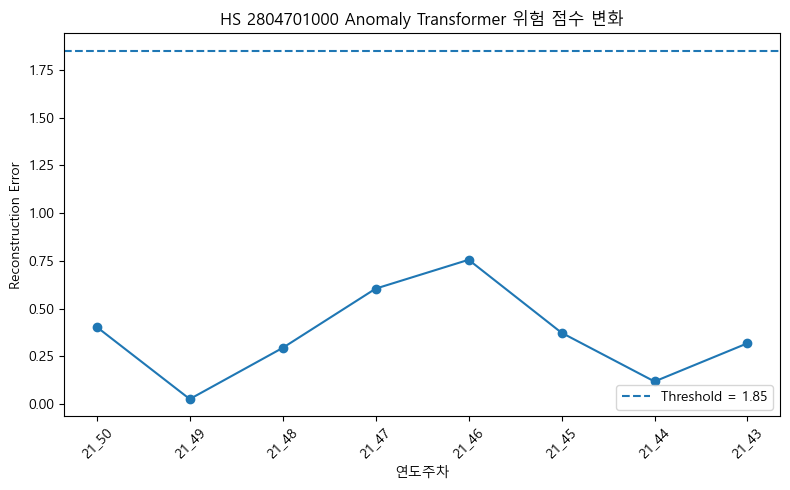

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_03 0.759  506508.750
1    17_04 0.735  936849.355
2    17_05 0.734  930738.055
3    17_06 0.754  893311.305
4    17_07 0.756 1637404.305
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]


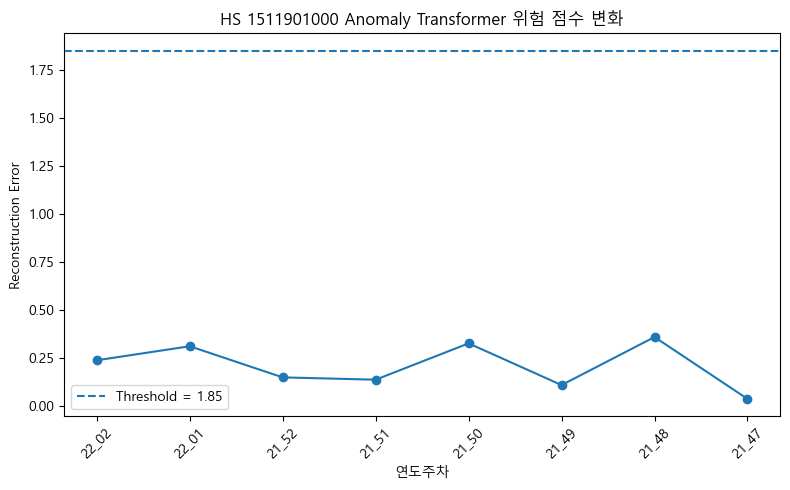

HS Code : 305531000
      연도주차     단가       신고중량
0    17_03 10.065  96064.000
1    17_04 10.143 112739.000
2    17_05 10.020 106671.250
3    17_06  9.953 107973.500
4    17_07  9.665  98612.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]


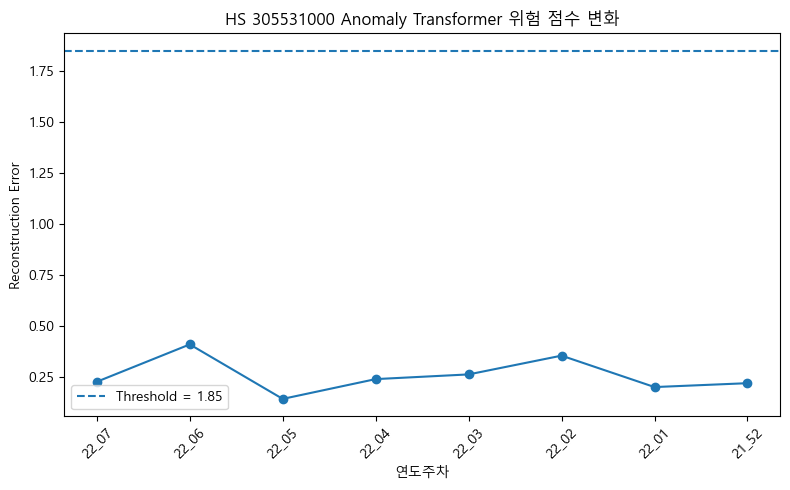

HS Code : 302140000
      연도주차     단가       신고중량
0    17_03 12.501 190731.825
1    17_04 12.297 248997.765
2    17_05 11.776 247770.110
3    17_06 11.204 258943.758
4    17_07 10.781 262438.498
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]


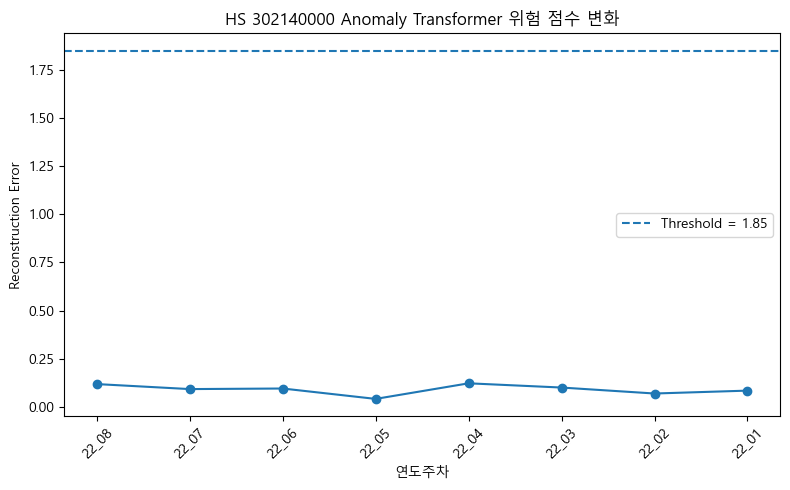

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_03 0.288 1533750.000
1    17_04 0.288 1533750.000
2    17_05 0.288 1533750.000
3    17_06 0.288 1533750.000
4    17_07 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]


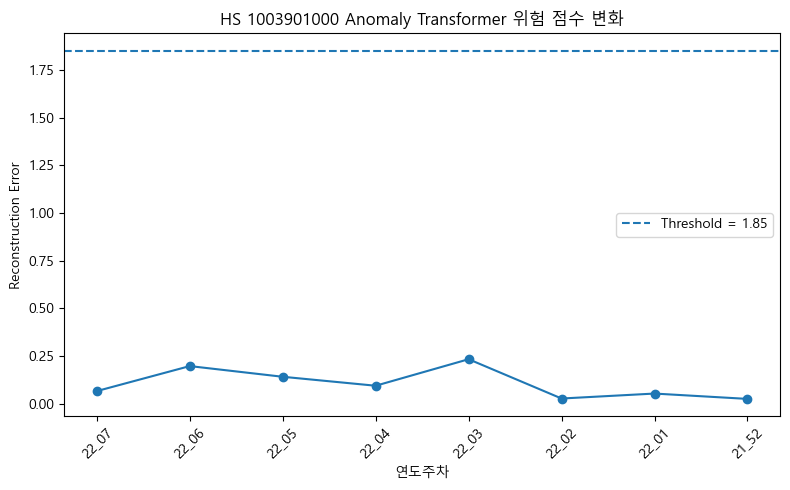

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_03 0.192 1642500.000
1    17_04 0.192 3149912.500
2    17_05 0.192 3412412.500
3    17_06 0.192 2054420.000
4    17_07 0.192 1861815.000
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]


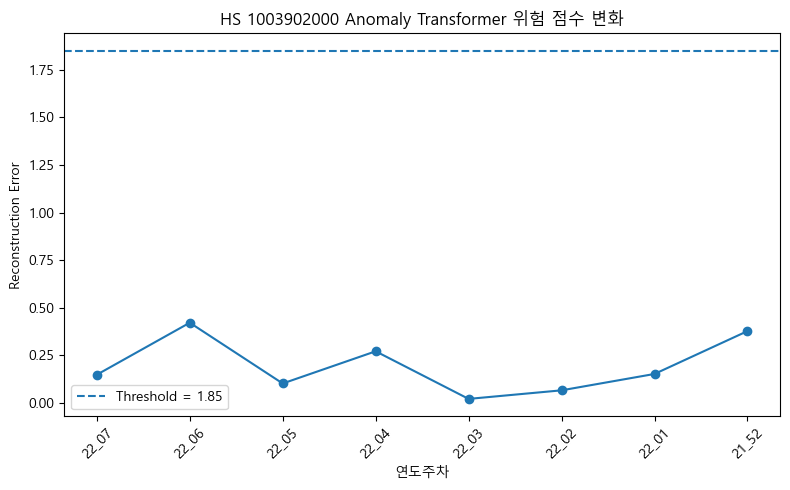

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_03 0.389  38475.125
1    17_04 0.389  38475.125
2    17_05 0.430 166375.125
3    17_06 0.477 415325.600
4    17_07 0.478 462700.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]


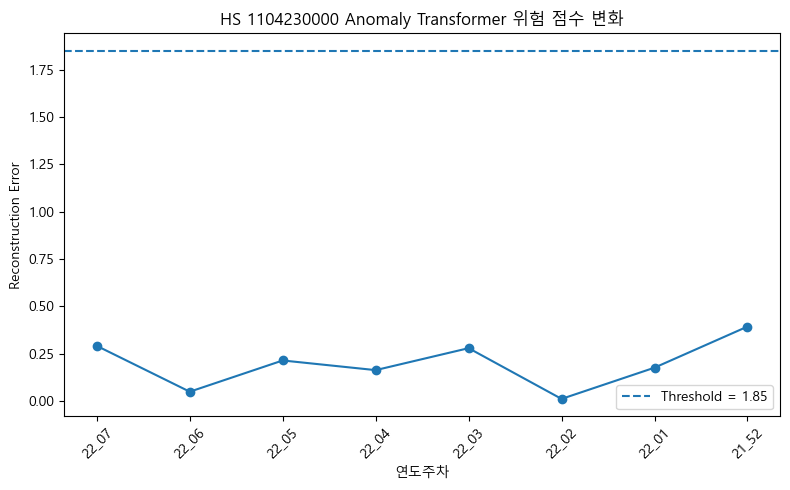

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_03 0.551  2149886.250
1    17_04 0.551  2149886.250
2    17_05 0.550  4114309.500
3    17_06 0.549  6381111.750
4    17_07 0.549  4234150.250
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]


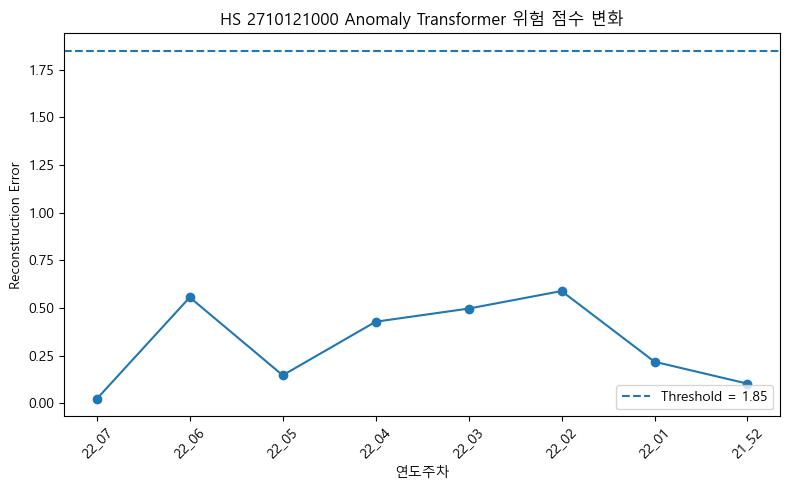

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_03 0.299 11374075.375
1    17_04 0.299 11374102.375
2    17_05 0.298 16317880.400
3    17_06 0.291 12415604.100
4    17_07 0.291 10819745.700
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]


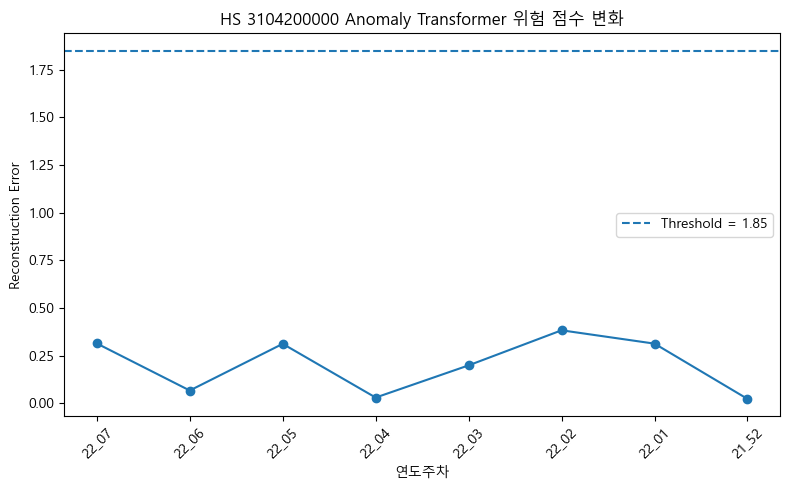

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_03 1.754  40702.550
1    17_04 1.801  49211.300
2    17_05 1.754  65983.925
3    17_06 1.838  79977.625
4    17_07 1.857  61760.131
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]


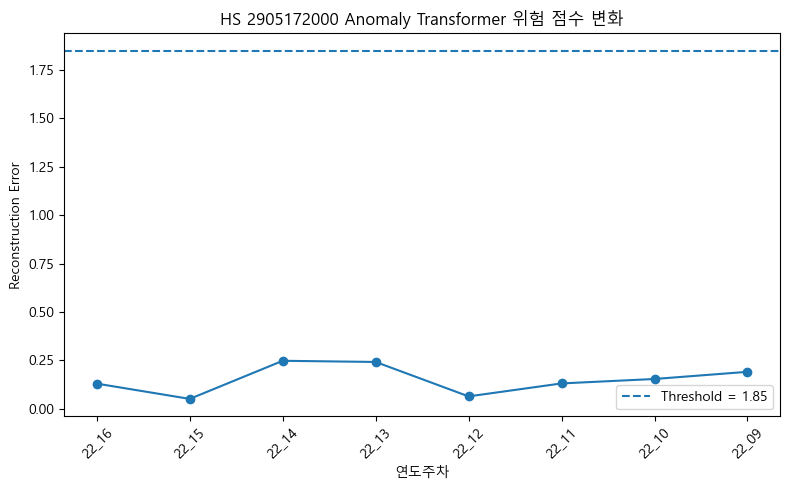

In [6]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
threshold = 1.85

# ==================================================
# 품목별 반복
# ==================================================
j = 0

for hs in 추출용:

    print(f'HS Code : {hs}')

    # 품목마다 e 초기화
    e = [0] * 8

    data = pd.DataFrame(columns=use_col)
    data = pd.concat([
        data,
        original[original['HS10단위부호'] == str(hs)]
    ])

    data = data.reset_index(drop=True)
    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)

    # ==================================================
    # 주차별 수입단가 및 신고중량 생성
    # ==================================================
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]

    df_price_week = (
        df_price
        .groupby('연도주차')[['과세가격미화금액', '신고중량']]
        .agg(['sum'])
        .reset_index()
    )

    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']

    # 수입이 없는 주차 생성
    df_price_week_hole = pd.DataFrame(columns=df_price_week.columns)

    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([
            df_price_week_hole,
            pd.DataFrame([{
                '연도주차': wk,
                '과세가격미화금액': 0,
                '신고중량': 0
            }])
        ], ignore_index=True)

    df_price_week_total = (
        pd.concat([df_price_week, df_price_week_hole])
        .sort_values('연도주차')
        .reset_index(drop=True)
    )

    # ==================================================
    # 직전 4주 평균
    # ==================================================
    price_w4 = []
    kg_w4 = []

    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(
            df_price_week_total[['과세가격미화금액']]
            .iloc[x:x + 4]
            .mean()
            .iloc[0]
        )

        kg_w4.append(
            df_price_week_total[['신고중량']]
            .iloc[x:x + 4]
            .mean()
            .iloc[0]
        )

    df_price_4w = df_price_week_total.iloc[3:].copy()

    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4

    df_price_4w = df_price_4w.reset_index(drop=True)

    df_price_4w['과세가격미화금액'] = (
        df_price_4w['과세가격미화금액']
        .replace(0, np.nan)
        .ffill()
    )

    df_price_4w['신고중량'] = (
        df_price_4w['신고중량']
        .replace(0, np.nan)
        .ffill()
    )

    df_price_4w['단가'] = (
        df_price_4w['과세가격미화금액'] /
        df_price_4w['신고중량']
    )

    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    df_price_4w = df_price_4w.replace([np.inf, -np.inf], np.nan)
    df_price_4w[['단가', '신고중량']] = df_price_4w[['단가', '신고중량']].ffill().bfill()

    print(df_price_4w)

    # ==================================================
    # 학습 데이터 생성
    # ==================================================
    train_data = df_price_4w[['단가', '신고중량']].values.astype(np.float32)

    train_data = np.nan_to_num(
        train_data,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # 표준화
    scaler = StandardScaler()
    train_data_scaled = scaler.fit_transform(train_data)

    # 8주 window 생성
    train_windows = make_windows(train_data_scaled, window_size=8)

    if len(train_windows) == 0:
        print(f"{hs} 품목은 학습 가능한 window가 부족합니다.")
        j += 1
        continue

    # ==================================================
    # Anomaly Transformer 모델 생성 및 학습
    # ==================================================
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    
    model = AnomalyTransformer(
        input_dim=2,
        d_model=128,
        num_heads=8,
        sigma=1.0
    )

    model = train_anomaly_transformer(
        model,
        train_windows,
        epochs=100,
        lr=0.001,
        lambda_dis=0.01
    )

    model.eval()

    # ==================================================
    # 학습된 모델로 최근 8개 구간 reconstruction error 계산
    # ==================================================
    for l in range(b[j] - 8, b[j]):

        segment = df_price_4w.iloc[
            p_eriod - l - 8 : p_eriod - l
        ][['단가', '신고중량']].values.astype(np.float32)

        if segment.shape[0] < 8:
            continue

        segment = np.nan_to_num(
            segment,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # 학습 때 사용한 scaler를 그대로 적용
        segment_scaled = scaler.transform(segment)

        input_tensor = torch.tensor(
            segment_scaled,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            output_tensor, _ = model(input_tensor)

        recon_error = (
            ((output_tensor - input_tensor) ** 2)
            .sum(dim=-1)
            .sqrt()
            .detach()
            .numpy()
        )

        last_error = recon_error[0, -1]

        e[l - b[j] + 8] = round(float(last_error), 3)

        if last_error > threshold:
            k[j] += 1

        if z[j] < last_error:
            z[j] = round(float(last_error), 3)
            c[j] = l

    # ==================================================
    # 위험경보 여부
    # ==================================================
    if z[j] > threshold:
        o[j] = 1

    # ==================================================
    # 그래프
    # ==================================================
    plt.rc('font', family='Malgun Gothic')
    plt.rc('axes', unicode_minus=False)

    x_labels = [
        df_price_4w['연도주차'].iloc[-1 - l]
        for l in range(b[j] - 8, b[j])
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(x_labels, e, marker='o')
    plt.axhline(y=threshold, linestyle='--', label=f'Threshold = {threshold}')
    plt.xticks(rotation=45)
    plt.xlabel("연도주차")
    plt.ylabel("Reconstruction Error")
    plt.title(f"HS {hs} Anomaly Transformer 위험 점수 변화")
    plt.legend()
    plt.tight_layout()
    plt.show()

    j += 1


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model29(1)'] = o
collect.loc[15, 'Model29(1)'] = np.sum(o)
collect.loc[:14, 'Model29(2)'] = z
collect.loc[15, 'Model29(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[30]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[30]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[30]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
      연도주차     단가        신고중량
0    17_03 12.223  782966.682
1    17_04 12.645 1025925.581
2    17_05 12.325 1003770.569
3    17_06 12.990  896546.704
4    17_07 13.868  810003.951
..     ...    ...         ...
292  22_34 12.959 1815633.348
293  22_35 12.448 1915482.234
294  22_36 12.514 1804240.198
295  22_37 13.038 1895153.324
296  22_38 12.894 1863081.698

[297 rows x 3 columns]


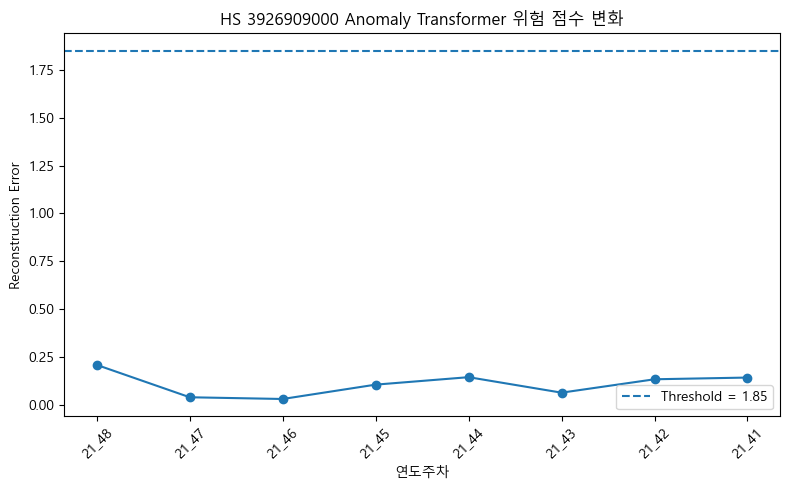

HS Code : 7326909000
      연도주차    단가        신고중량
0    17_03 3.248 7163222.401
1    17_04 3.239 9168390.099
2    17_05 3.083 8986749.600
3    17_06 3.218 8269841.990
4    17_07 3.697 7854248.619
..     ...   ...         ...
292  22_34 4.186 8816636.180
293  22_35 4.134 8974905.138
294  22_36 4.075 8042241.078
295  22_37 4.002 8195776.474
296  22_38 4.381 7865576.680

[297 rows x 3 columns]


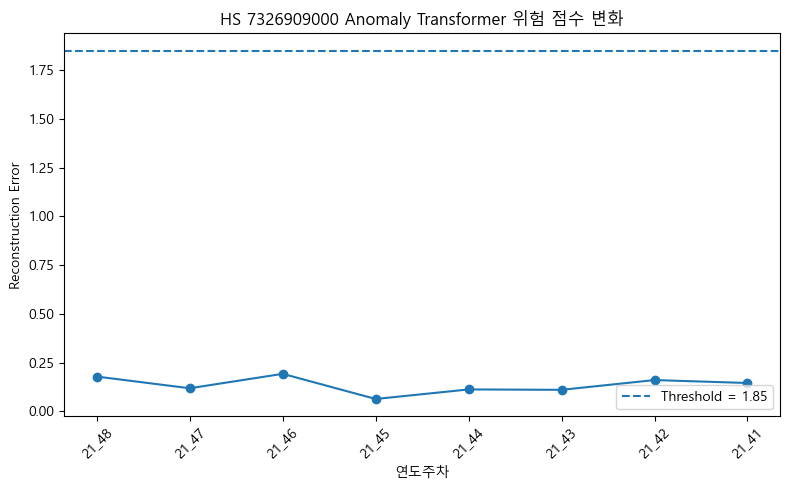

HS Code : 8708999000
      연도주차     단가        신고중량
0    17_03 14.377  996625.281
1    17_04 14.075 1247682.893
2    17_05 13.650 1234876.845
3    17_06 13.754 1169274.438
4    17_07 14.186 1085290.376
..     ...    ...         ...
292  22_34 14.548 1197477.282
293  22_35 14.015 1312549.034
294  22_36 14.086 1032812.910
295  22_37 13.684 1069049.869
296  22_38 13.629 1100040.657

[297 rows x 3 columns]


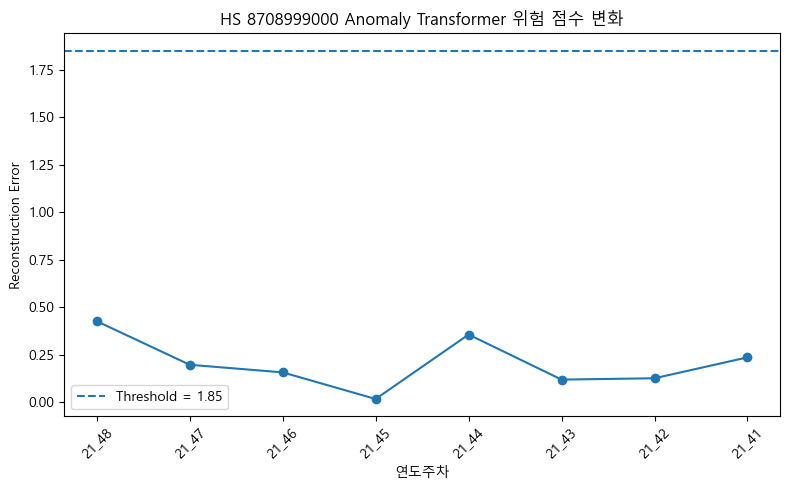

HS Code : 2106909099
      연도주차     단가        신고중량
0    17_03 16.939  849236.424
1    17_04 16.567 1096069.847
2    17_05 17.445 1090277.061
3    17_06 18.573 1065622.447
4    17_07 17.266 1079067.502
..     ...    ...         ...
292  22_34 22.993 1792636.330
293  22_35 23.689 1812879.627
294  22_36 22.930 1733061.597
295  22_37 24.824 1557516.093
296  22_38 22.206 1725581.801

[297 rows x 3 columns]


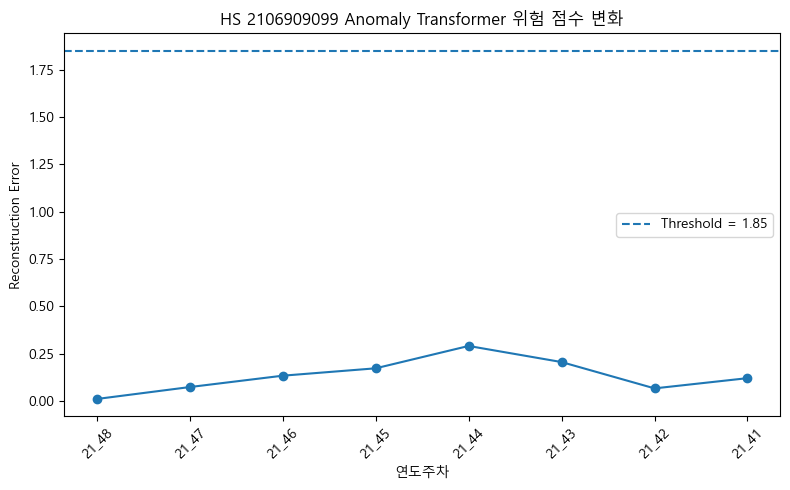

HS Code : 4911990000
      연도주차     단가      신고중량
0    17_03 35.047 14353.544
1    17_04 32.321 19529.869
2    17_05 30.090 19750.013
3    17_06 35.127 18579.112
4    17_07 50.896 16942.203
..     ...    ...       ...
292  22_34 59.026 36373.505
293  22_35 53.129 31194.135
294  22_36 53.195 26486.489
295  22_37 46.858 28118.647
296  22_38 28.951 31057.943

[297 rows x 3 columns]


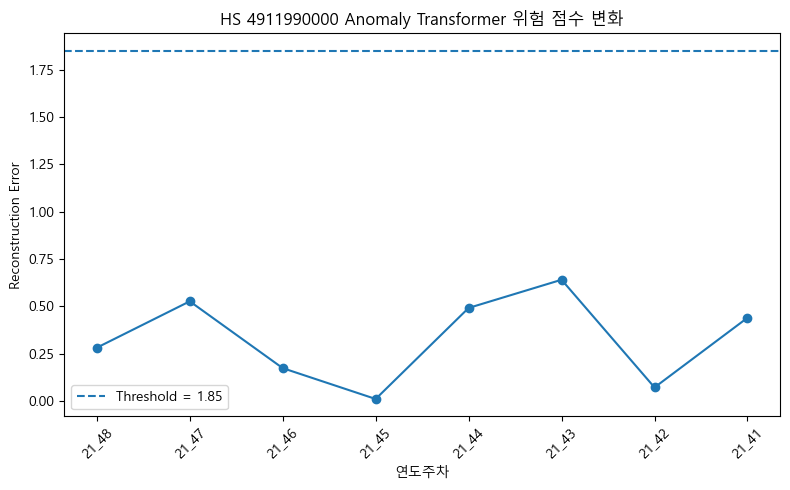

HS Code : 6403999000
      연도주차     단가       신고중량
0    17_03 40.532 239458.691
1    17_04 42.573 307600.675
2    17_05 42.202 332294.615
3    17_06 45.631 292290.022
4    17_07 45.425 288711.050
..     ...    ...        ...
292  22_34 49.753 314483.035
293  22_35 48.361 319968.488
294  22_36 46.162 307661.767
295  22_37 44.059 322508.380
296  22_38 45.232 312421.980

[297 rows x 3 columns]


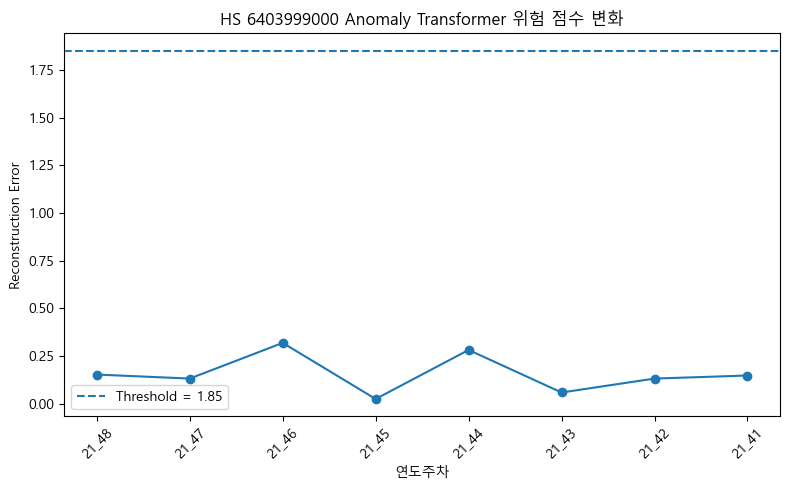

HS Code : 9031809099
      연도주차      단가       신고중량
0    17_03 129.965 133834.260
1    17_04 129.171 157944.184
2    17_05 108.770 155291.110
3    17_06 108.294 172098.109
4    17_07 128.855 142177.506
..     ...     ...        ...
292  22_34 107.316 196206.079
293  22_35 115.643 201236.136
294  22_36 132.293 185872.607
295  22_37 136.131 174217.334
296  22_38 152.741 143387.679

[297 rows x 3 columns]


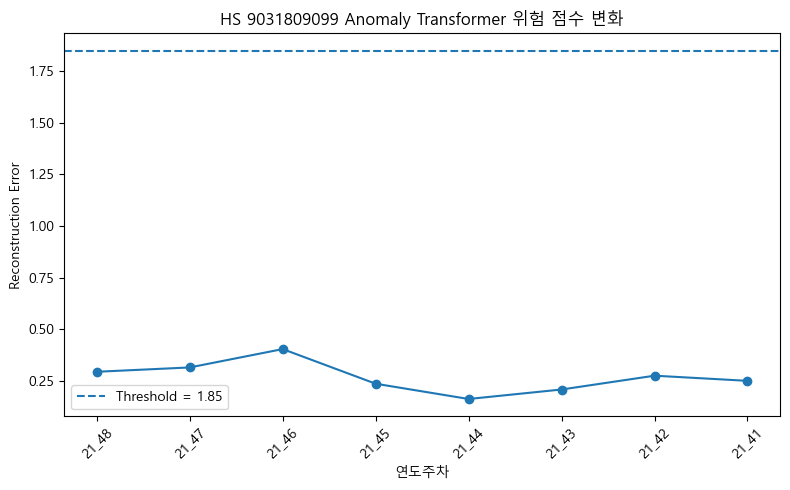

HS Code : 8542391000
      연도주차       단가      신고중량
0    17_03 1752.133 50613.219
1    17_04 1776.562 62373.847
2    17_05 1710.646 56980.096
3    17_06 1700.125 57142.753
4    17_07 1745.668 57212.506
..     ...      ...       ...
292  22_34 3218.867 57436.982
293  22_35 3041.957 57382.773
294  22_36 3111.084 55815.490
295  22_37 3258.838 54519.836
296  22_38 3379.894 54799.348

[297 rows x 3 columns]


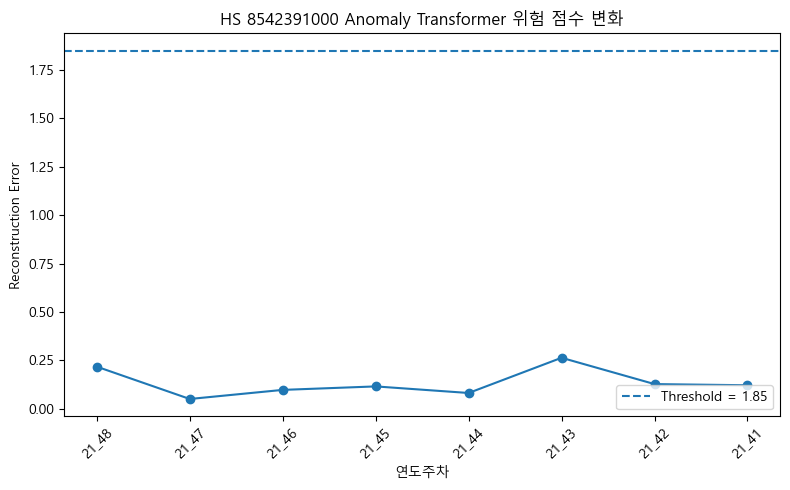

HS Code : 6109101000
      연도주차     단가       신고중량
0    17_03 19.615 330727.719
1    17_04 20.080 407322.358
2    17_05 21.565 369330.457
3    17_06 22.951 328115.994
4    17_07 22.459 320495.424
..     ...    ...        ...
292  22_34 24.510 331834.580
293  22_35 22.816 352385.923
294  22_36 22.607 312789.645
295  22_37 21.972 286627.134
296  22_38 21.345 268384.628

[297 rows x 3 columns]


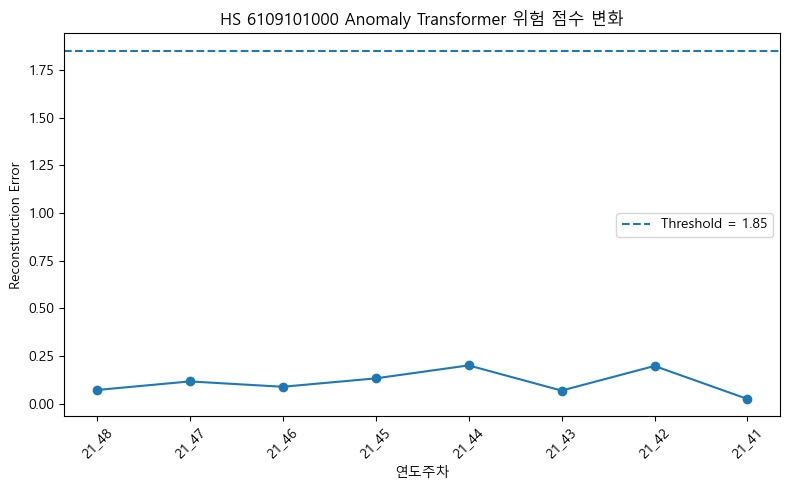

HS Code : 2934996000
      연도주차     단가      신고중량
0    17_03  8.610 32516.848
1    17_04  8.498 49632.923
2    17_05  8.632 57464.182
3    17_06  8.808 60682.206
4    17_07  8.798 59678.369
..     ...    ...       ...
292  22_34 45.139 18624.338
293  22_35 69.964 11267.689
294  22_36 45.700 15034.463
295  22_37 19.447 15005.874
296  22_38 25.918  6977.896

[297 rows x 3 columns]


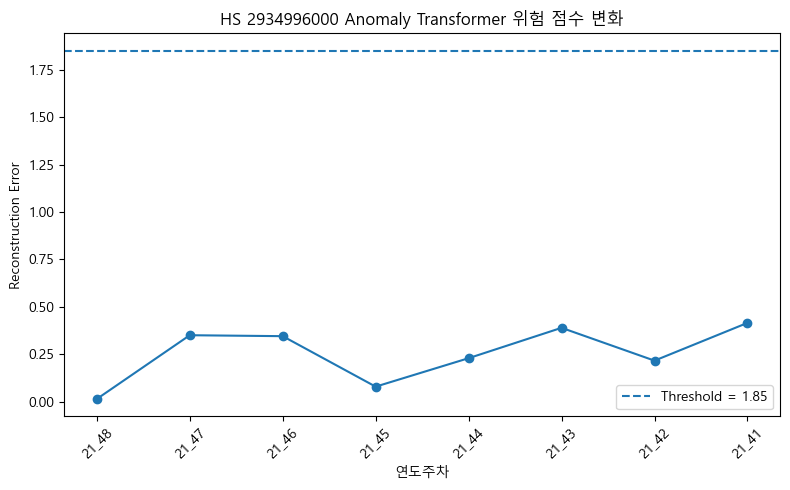

HS Code : 4016930000
      연도주차     단가       신고중량
0    17_03 32.361  73089.712
1    17_04 33.773  88152.130
2    17_05 37.114  84985.181
3    17_06 39.994  84495.300
4    17_07 43.464  79589.242
..     ...    ...        ...
292  22_34 35.527 100362.256
293  22_35 34.124 116410.851
294  22_36 36.241  93017.522
295  22_37 39.299  82961.592
296  22_38 41.360  81901.151

[297 rows x 3 columns]


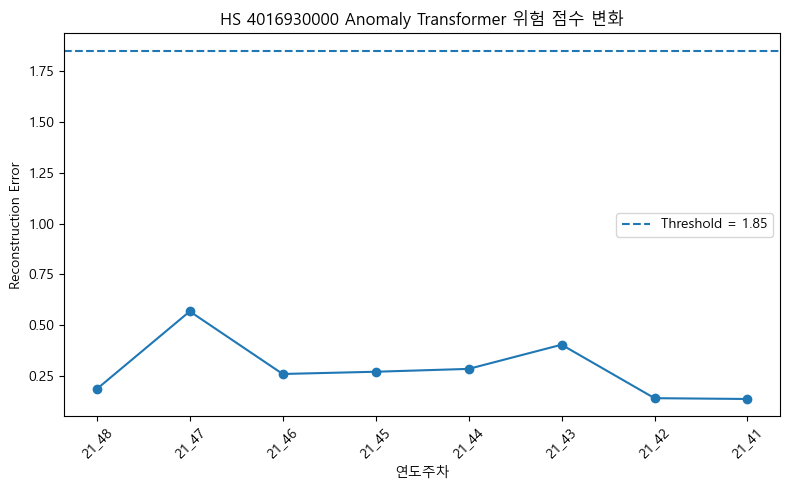

HS Code : 6110200000
      연도주차     단가       신고중량
0    17_03 22.047 297397.679
1    17_04 22.240 361785.894
2    17_05 24.727 298878.713
3    17_06 27.402 225267.700
4    17_07 29.106 175229.062
..     ...    ...        ...
292  22_34 27.774 616067.789
293  22_35 27.079 664306.128
294  22_36 27.678 633297.234
295  22_37 26.838 616346.393
296  22_38 27.102 584630.699

[297 rows x 3 columns]


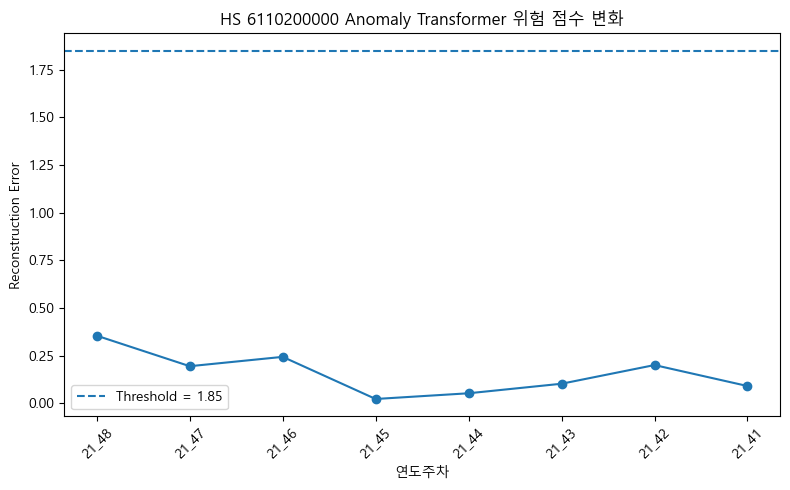

HS Code : 6211499000
      연도주차      단가      신고중량
0    17_03  43.166 19028.221
1    17_04  36.351 26163.515
2    17_05  35.936 24753.456
3    17_06  29.483 23216.503
4    17_07  32.605 19810.625
..     ...     ...       ...
292  22_34 124.614 33354.493
293  22_35 126.914 32804.025
294  22_36 134.758 30045.096
295  22_37 130.125 33029.579
296  22_38 136.045 31698.336

[297 rows x 3 columns]


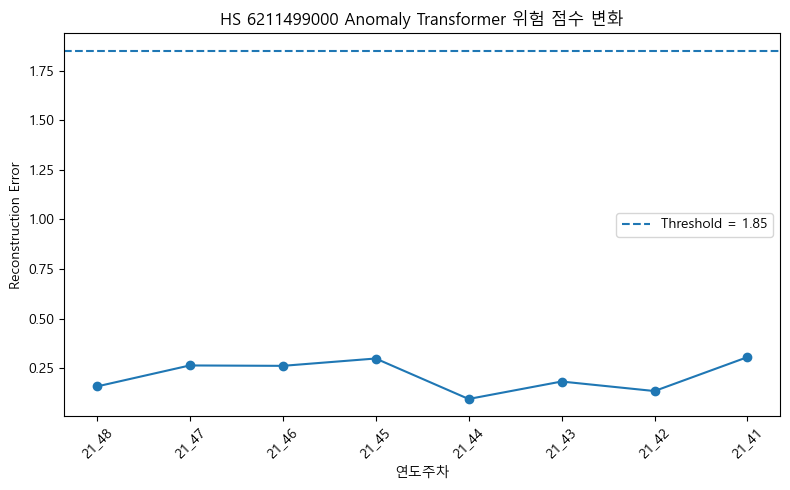

HS Code : 4202999000
      연도주차     단가       신고중량
0    17_03 12.660  83859.535
1    17_04 11.930 114854.454
2    17_05 13.510  97367.585
3    17_06 15.117  84721.380
4    17_07 17.806  64762.410
..     ...    ...        ...
292  22_34 37.997  63336.199
293  22_35 37.557  67878.172
294  22_36 38.778  65572.161
295  22_37 37.615  71488.576
296  22_38 39.546  67800.206

[297 rows x 3 columns]


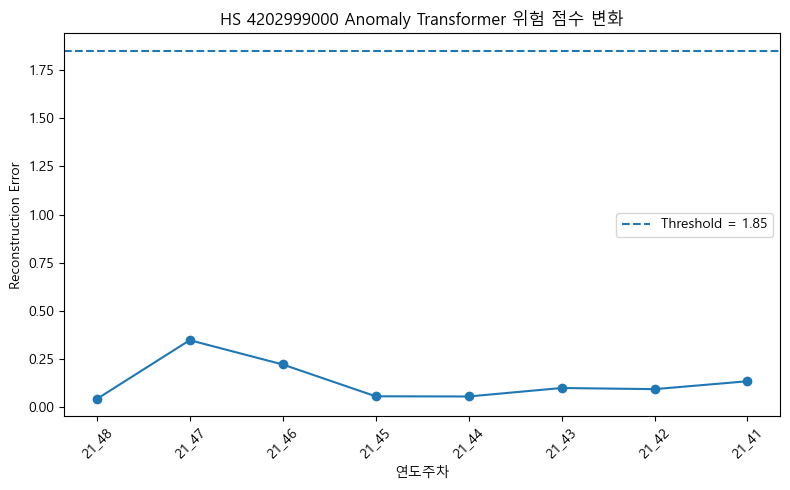

HS Code : 3304991000
      연도주차     단가       신고중량
0    17_03 52.671 316939.669
1    17_04 60.484 438875.551
2    17_05 62.220 442029.125
3    17_06 64.621 454161.740
4    17_07 65.076 437650.124
..     ...    ...        ...
292  22_34 86.153 803500.959
293  22_35 83.161 746905.818
294  22_36 86.268 602836.532
295  22_37 83.825 640390.917
296  22_38 88.960 667616.950

[297 rows x 3 columns]


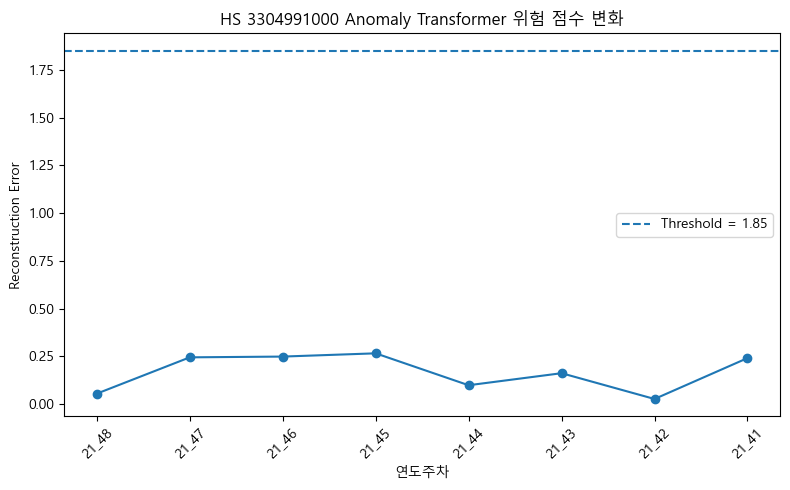

HS Code : 8544429090
      연도주차     단가       신고중량
0    17_03 23.188  99775.181
1    17_04 22.442 133268.811
2    17_05 19.936 150909.589
3    17_06 20.806 142360.843
4    17_07 20.254 134948.973
..     ...    ...        ...
292  22_34 31.205 121301.305
293  22_35 33.180 113849.449
294  22_36 38.848  95069.248
295  22_37 38.887  89062.672
296  22_38 38.639  83172.104

[297 rows x 3 columns]


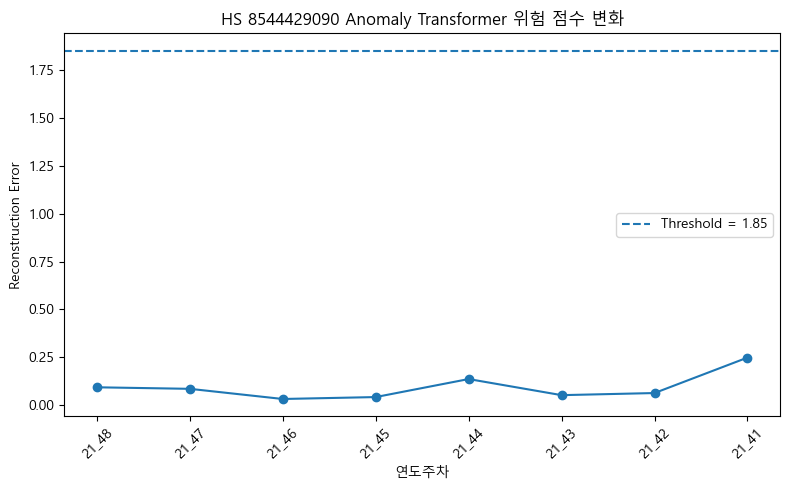

HS Code : 8481801090
      연도주차     단가       신고중량
0    17_03 25.149 639202.941
1    17_04 24.419 867375.544
2    17_05 24.743 877752.450
3    17_06 27.989 756466.539
4    17_07 30.936 683371.785
..     ...    ...        ...
292  22_34 35.294 664890.252
293  22_35 36.869 714942.677
294  22_36 40.011 597877.847
295  22_37 38.783 631414.445
296  22_38 37.918 612214.183

[297 rows x 3 columns]


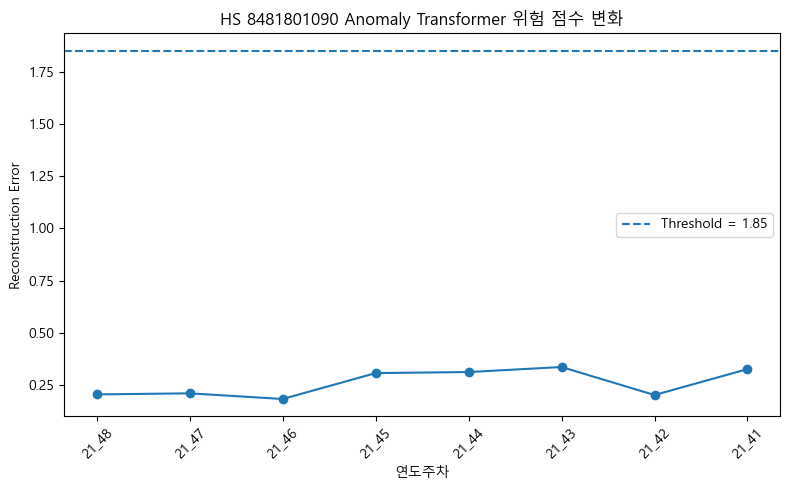

HS Code : 3304999000
      연도주차     단가      신고중량
0    17_03 42.777 58026.458
1    17_04 59.281 75607.321
2    17_05 63.561 76195.666
3    17_06 62.604 90904.970
4    17_07 68.242 84830.791
..     ...    ...       ...
292  22_34 76.922 63785.081
293  22_35 87.618 63696.939
294  22_36 87.240 57699.559
295  22_37 91.778 52287.780
296  22_38 96.245 62910.697

[297 rows x 3 columns]


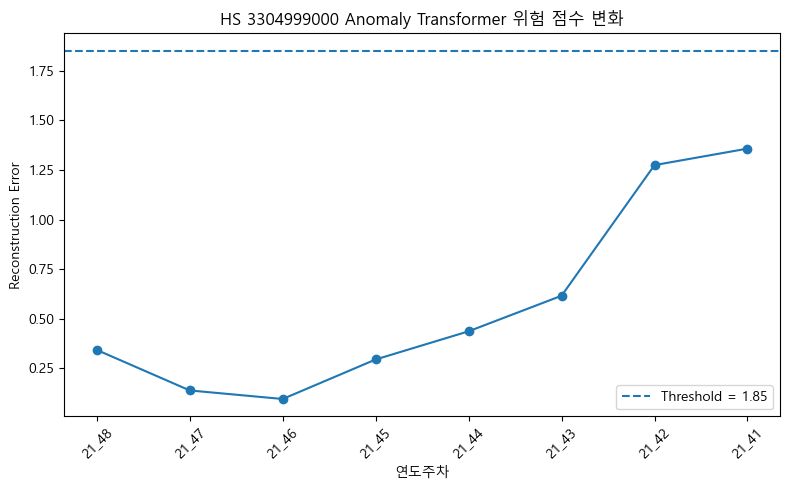

HS Code : 8543709090
      연도주차      단가       신고중량
0    17_03 235.081  45024.239
1    17_04 227.436  58874.088
2    17_05 224.701  57636.610
3    17_06 221.690  58398.750
4    17_07 223.516  58332.744
..     ...     ...        ...
292  22_34 219.972 115375.374
293  22_35 220.214 112118.800
294  22_36 239.236  99513.783
295  22_37 221.137 106693.282
296  22_38 231.450 106909.689

[297 rows x 3 columns]


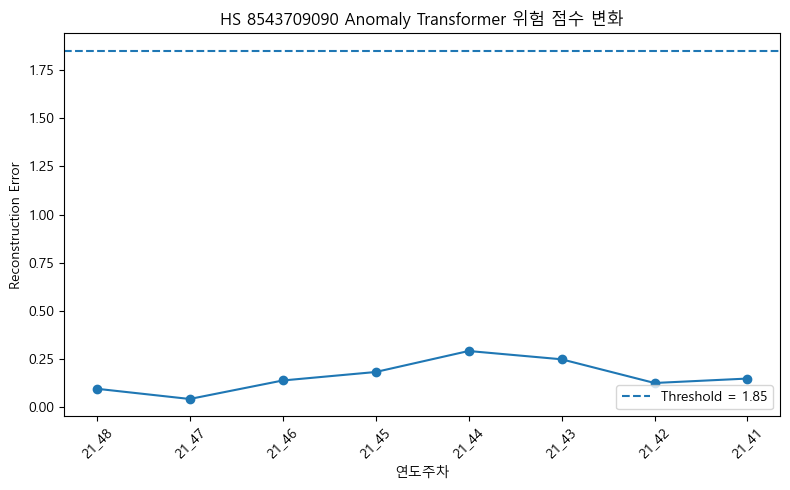

HS Code : 6404199000
      연도주차     단가       신고중량
0    17_03 24.497 321895.357
1    17_04 24.079 433706.005
2    17_05 24.276 489646.895
3    17_06 26.045 464463.766
4    17_07 26.715 411383.820
..     ...    ...        ...
292  22_34 26.210 464050.823
293  22_35 26.889 495340.597
294  22_36 26.242 544325.299
295  22_37 25.719 552088.040
296  22_38 26.210 549057.174

[297 rows x 3 columns]


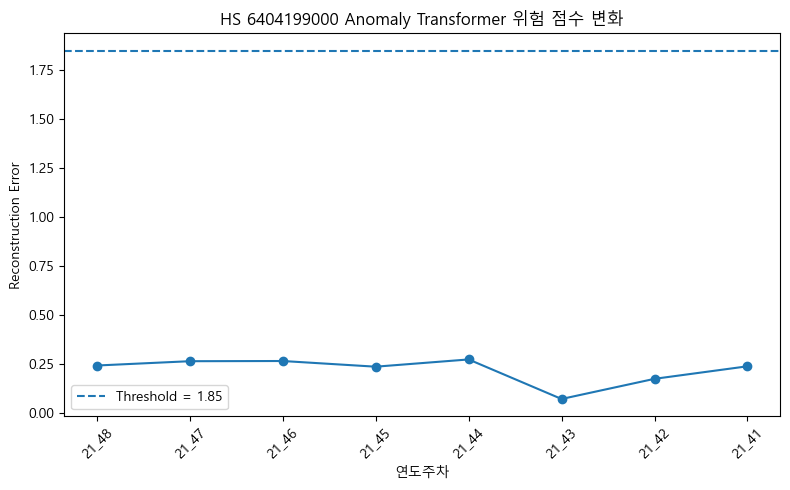

HS Code : 3004909900
      연도주차     단가        신고중량
0    17_03 55.419  620601.439
1    17_04 50.256  813208.066
2    17_05 51.854  857624.964
3    17_06 48.439  877252.749
4    17_07 42.512  922404.462
..     ...    ...         ...
292  22_34 46.072 1100536.037
293  22_35 50.953 1040200.013
294  22_36 64.322  954193.409
295  22_37 57.557 1010066.636
296  22_38 54.954 1152317.664

[297 rows x 3 columns]


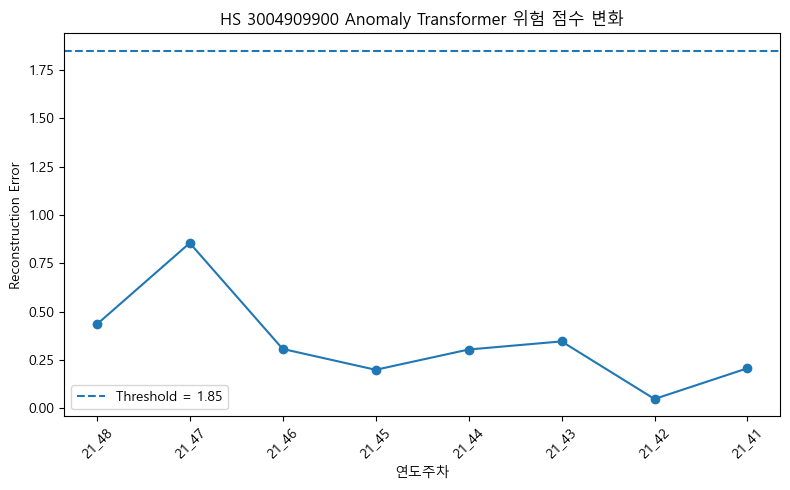

HS Code : 8542311000
      연도주차       단가      신고중량
0    17_03 4703.113 49010.551
1    17_04 4617.302 62174.914
2    17_05 4600.665 59881.381
3    17_06 4609.463 60889.965
4    17_07 4683.508 60436.896
..     ...      ...       ...
292  22_34 7870.564 75278.936
293  22_35 7828.619 75478.242
294  22_36 7860.660 70760.202
295  22_37 8124.353 74194.129
296  22_38 8210.185 72670.298

[297 rows x 3 columns]


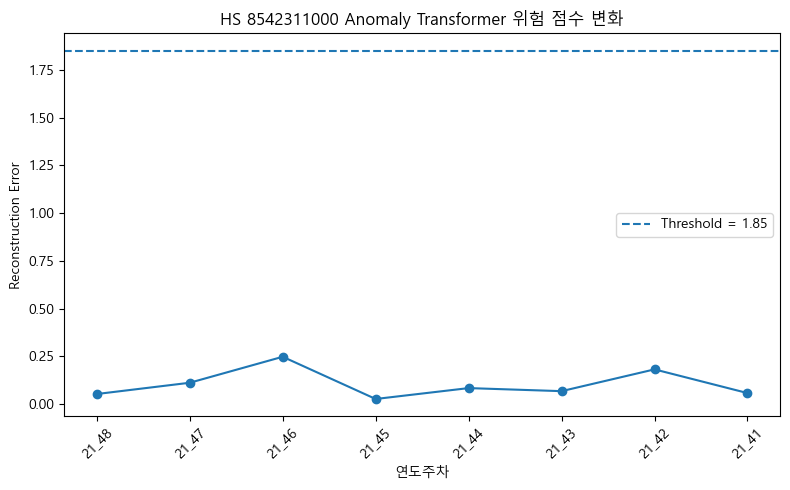

HS Code : 4901999000
      연도주차     단가       신고중량
0    17_03 17.467  76369.925
1    17_04 17.640 100175.458
2    17_05 16.106 131106.952
3    17_06 17.220 130545.646
4    17_07 17.322 141892.769
..     ...    ...        ...
292  22_34 19.195 108195.469
293  22_35 18.625 118643.860
294  22_36 18.841  99451.189
295  22_37 20.885  86145.057
296  22_38 20.862  80884.167

[297 rows x 3 columns]


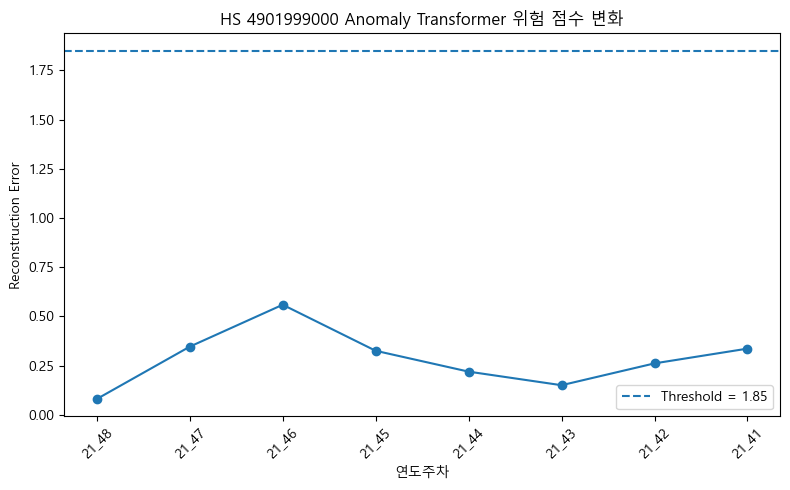

HS Code : 8473309090
      연도주차      단가      신고중량
0    17_03 112.480 70365.007
1    17_04 103.438 98141.215
2    17_05  89.920 95195.908
3    17_06  93.011 93596.876
4    17_07  91.536 89812.626
..     ...     ...       ...
292  22_34 127.420 64333.353
293  22_35 126.451 67401.267
294  22_36 120.080 64354.283
295  22_37 133.878 60193.390
296  22_38 125.217 63691.076

[297 rows x 3 columns]


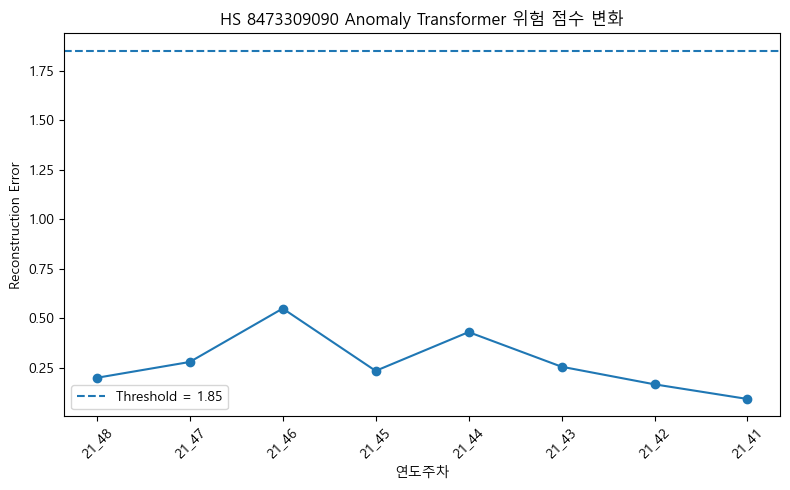

HS Code : 6307909000
      연도주차    단가       신고중량
0    17_03 5.679 444751.909
1    17_04 5.604 594914.831
2    17_05 5.820 550737.782
3    17_06 5.679 491903.032
4    17_07 6.246 378045.128
..     ...   ...        ...
292  22_34 8.968 594296.857
293  22_35 8.516 634583.744
294  22_36 8.467 620683.383
295  22_37 8.579 658795.785
296  22_38 8.369 682976.044

[297 rows x 3 columns]


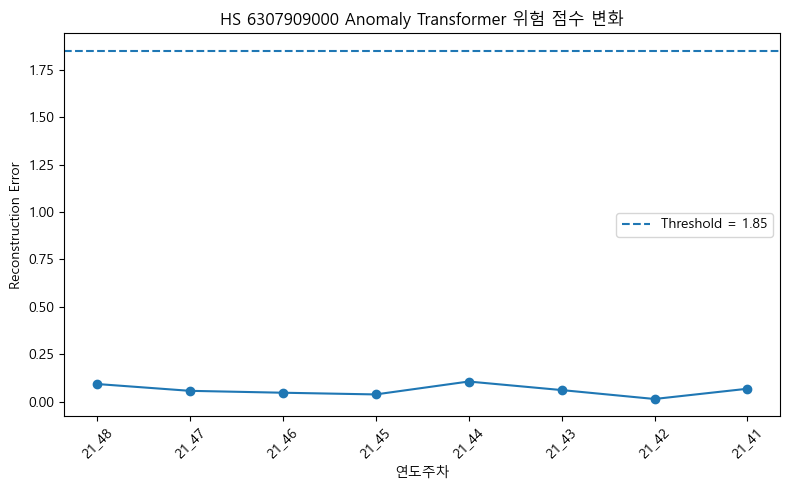

HS Code : 4202211090
      연도주차      단가      신고중량
0    17_03 235.355 62455.998
1    17_04 241.437 86358.604
2    17_05 253.736 85259.408
3    17_06 287.815 77440.904
4    17_07 347.777 64710.518
..     ...     ...       ...
292  22_34 426.882 64018.511
293  22_35 384.009 63360.915
294  22_36 408.313 55806.285
295  22_37 391.068 57839.474
296  22_38 397.270 60499.710

[297 rows x 3 columns]


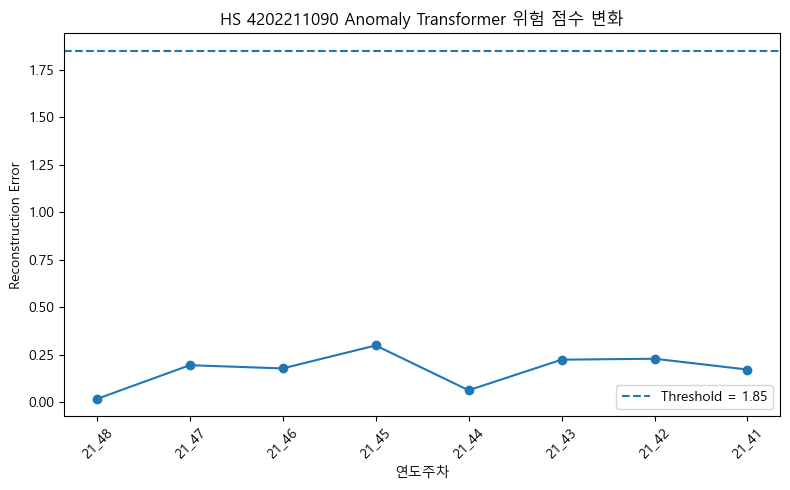

HS Code : 8536509090
      연도주차     단가      신고중량
0    17_03 85.604 57394.793
1    17_04 85.591 74933.006
2    17_05 87.512 69296.354
3    17_06 95.478 64834.179
4    17_07 93.794 64409.350
..     ...    ...       ...
292  22_34 84.772 55762.381
293  22_35 79.825 60339.219
294  22_36 75.518 59814.403
295  22_37 76.015 57586.281
296  22_38 76.158 55630.371

[297 rows x 3 columns]


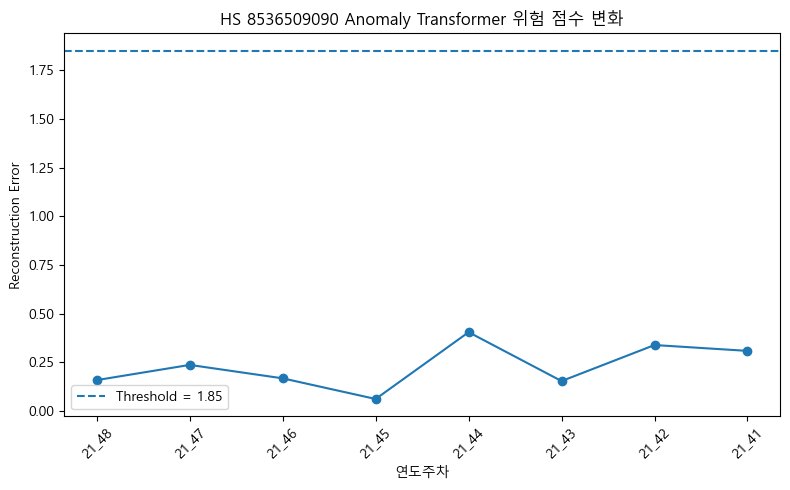

HS Code : 8538909000
      연도주차     단가       신고중량
0    17_03 43.734 218027.851
1    17_04 44.245 273949.515
2    17_05 46.217 278870.289
3    17_06 43.802 267217.483
4    17_07 44.970 288166.458
..     ...    ...        ...
292  22_34 44.666 240827.022
293  22_35 43.916 246156.983
294  22_36 46.418 221859.859
295  22_37 46.694 206086.687
296  22_38 47.247 203948.780

[297 rows x 3 columns]


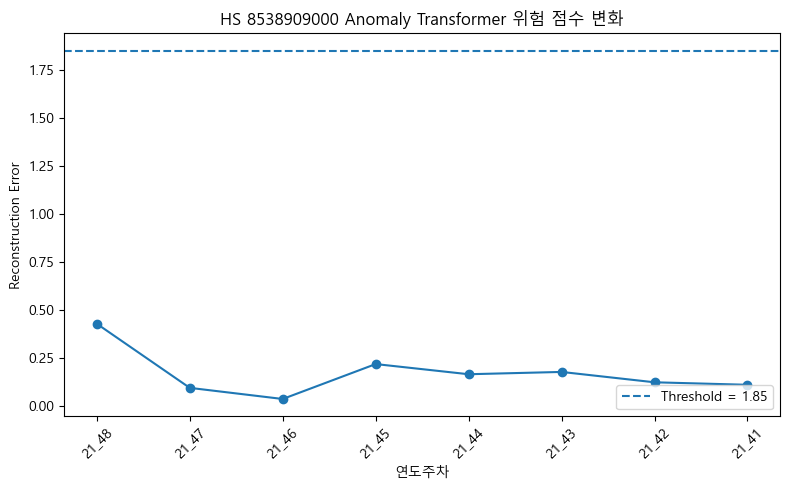

HS Code : 8479909090
      연도주차     단가       신고중량
0    17_03 80.961 111923.635
1    17_04 70.234 150477.045
2    17_05 69.507 140607.283
3    17_06 75.512 131932.099
4    17_07 69.869 124617.381
..     ...    ...        ...
292  22_34 76.835 107975.626
293  22_35 69.784 129008.410
294  22_36 69.289 120004.101
295  22_37 70.436 116425.652
296  22_38 70.507 111990.197

[297 rows x 3 columns]


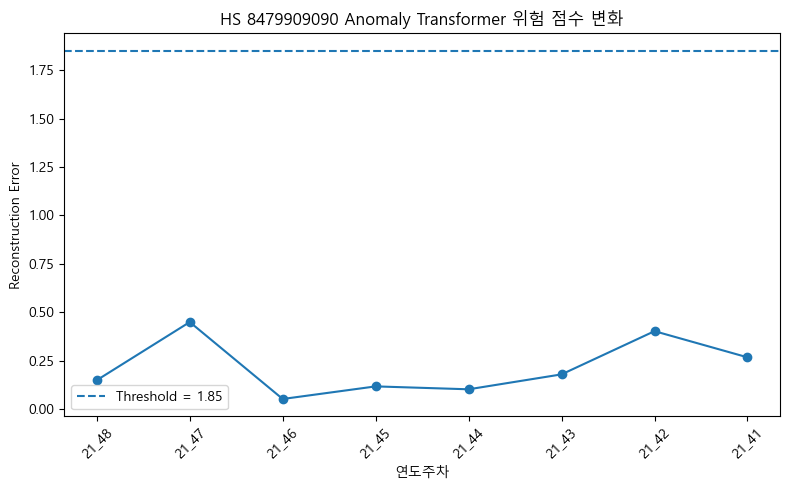

HS Code : 8504409099
      연도주차     단가       신고중량
0    17_03 51.071 102848.388
1    17_04 45.508 147796.603
2    17_05 46.117 144585.070
3    17_06 51.218 137630.769
4    17_07 53.410 149536.397
..     ...    ...        ...
292  22_34 87.083 169955.685
293  22_35 77.439 194442.378
294  22_36 68.709 179084.971
295  22_37 67.253 213412.513
296  22_38 68.693 204341.662

[297 rows x 3 columns]


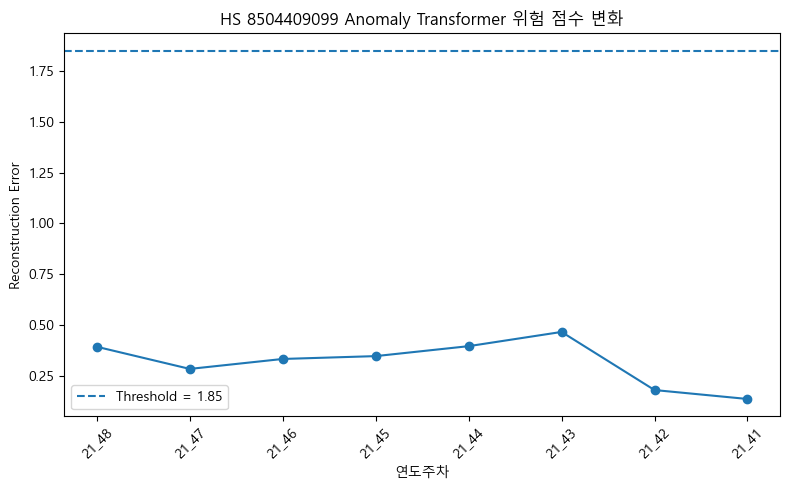

HS Code : 6110909000
      연도주차      단가      신고중량
0    17_03 118.750  6093.244
1    17_04 124.642  7195.191
2    17_05 142.168  7203.119
3    17_06 153.322  6683.793
4    17_07 144.904  7763.641
..     ...     ...       ...
292  22_34 217.578  6996.452
293  22_35 221.461  6778.470
294  22_36 213.702  7014.681
295  22_37 211.003  7409.746
296  22_38 163.716 10115.918

[297 rows x 3 columns]


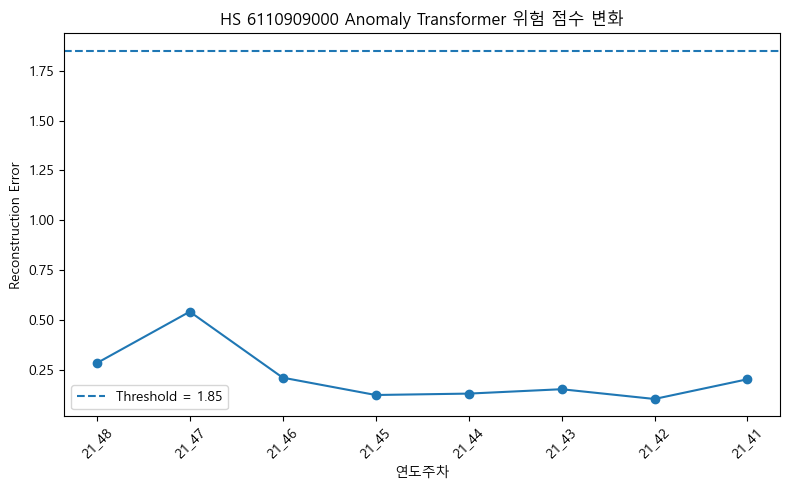

HS Code : 3923100000
      연도주차    단가        신고중량
0    17_03 3.818 1904848.636
1    17_04 3.845 2472212.036
2    17_05 3.947 2400024.796
3    17_06 3.963 2370141.074
4    17_07 3.924 2302460.438
..     ...   ...         ...
292  22_34 3.679 2783491.179
293  22_35 3.784 2712156.118
294  22_36 3.948 2329172.214
295  22_37 3.894 2485633.502
296  22_38 4.065 2371622.391

[297 rows x 3 columns]


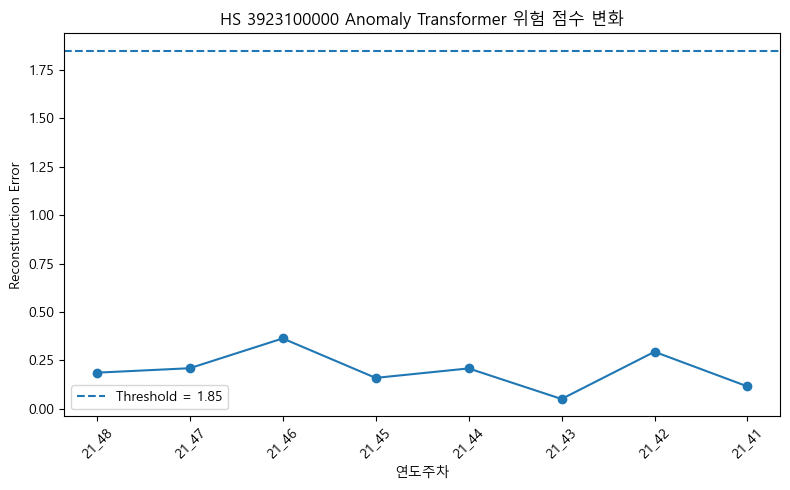

HS Code : 8544422090
      연도주차     단가       신고중량
0    17_03 16.131 336404.477
1    17_04 16.164 444903.567
2    17_05 16.603 414321.924
3    17_06 17.041 384241.238
4    17_07 16.985 366517.775
..     ...    ...        ...
292  22_34 23.253 456410.142
293  22_35 22.436 495383.218
294  22_36 21.952 493127.280
295  22_37 23.081 484107.434
296  22_38 22.899 479771.476

[297 rows x 3 columns]


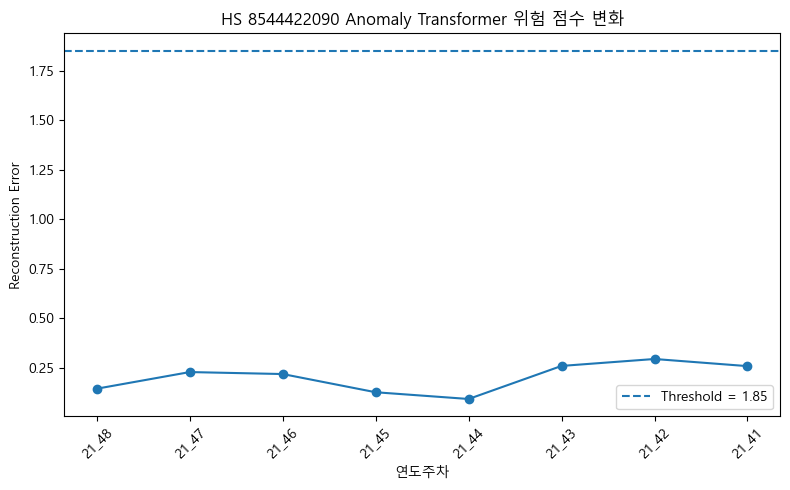

HS Code : 8537109000
      연도주차      단가       신고중량
0    17_03 100.497 100050.381
1    17_04 100.855 126453.495
2    17_05  95.918 129135.848
3    17_06  98.645 114158.314
4    17_07 110.859 115756.420
..     ...     ...        ...
292  22_34  26.557   1093.500
293  22_35  26.557   1093.500
294  22_36  26.557   1093.500
295  22_37  26.557   1093.500
296  22_38  26.557   1093.500

[297 rows x 3 columns]


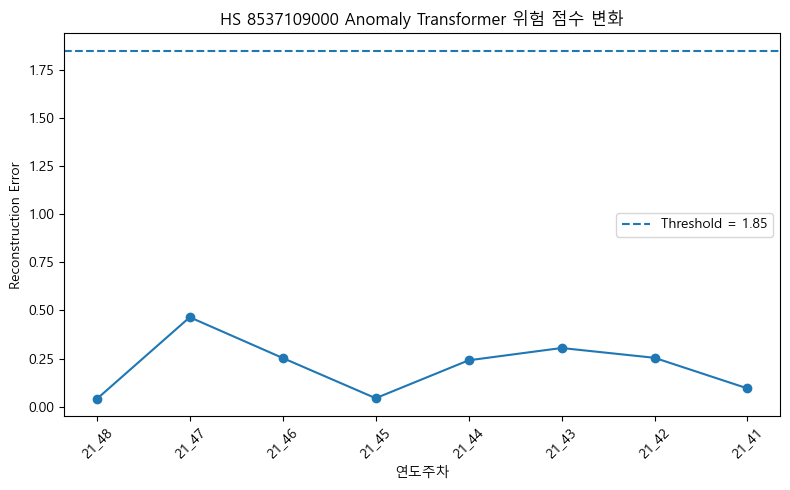

HS Code : 8536699000
      연도주차     단가       신고중량
0    17_03 49.984  62863.965
1    17_04 48.449  84011.851
2    17_05 50.615  84065.514
3    17_06 54.078  74430.699
4    17_07 54.518  71483.045
..     ...    ...        ...
292  22_34 43.083 103756.812
293  22_35 46.169 108270.748
294  22_36 43.516 106938.651
295  22_37 43.547 109731.120
296  22_38 43.044 109433.621

[297 rows x 3 columns]


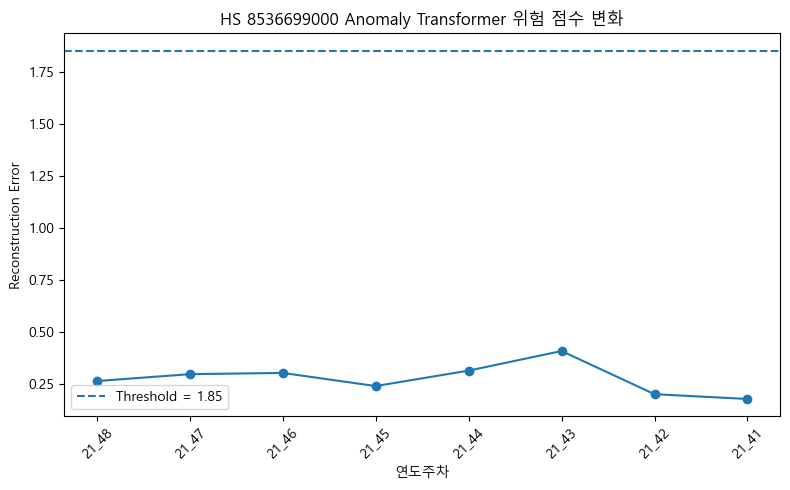

HS Code : 3102109000
      연도주차    단가         신고중량
0    17_03 0.252  4863455.150
1    17_04 0.255  5332959.546
2    17_05 0.262  6013912.829
3    17_06 0.266  5785572.955
4    17_07 0.274  6293268.930
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]


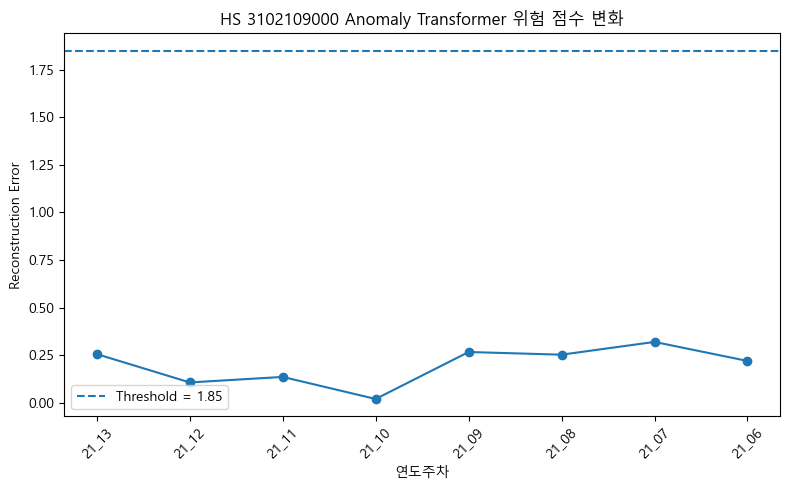

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_03 201.260 13493.463
1    17_04 219.044 17693.709
2    17_05 213.153 21010.400
3    17_06 216.113 19536.734
4    17_07 227.025 18619.221
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]


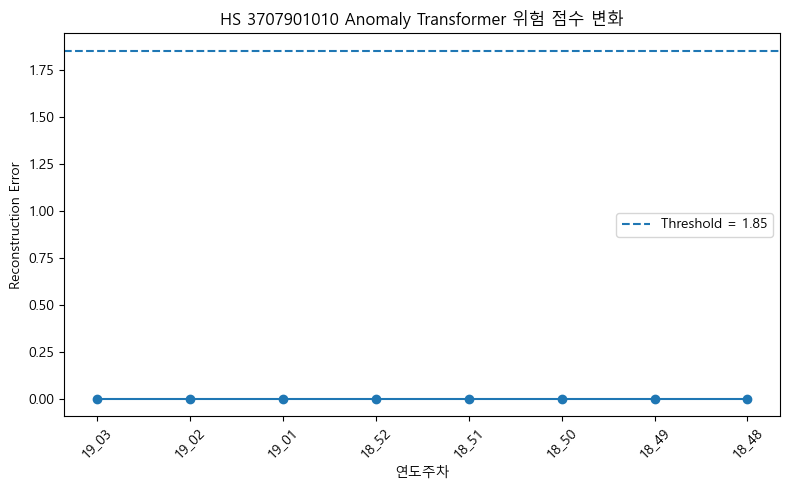

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_03 1.314 181711.497
1    17_04 1.321 239293.247
2    17_05 1.320 250460.747
3    17_06 1.335 267243.948
4    17_07 1.353 205743.000
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]


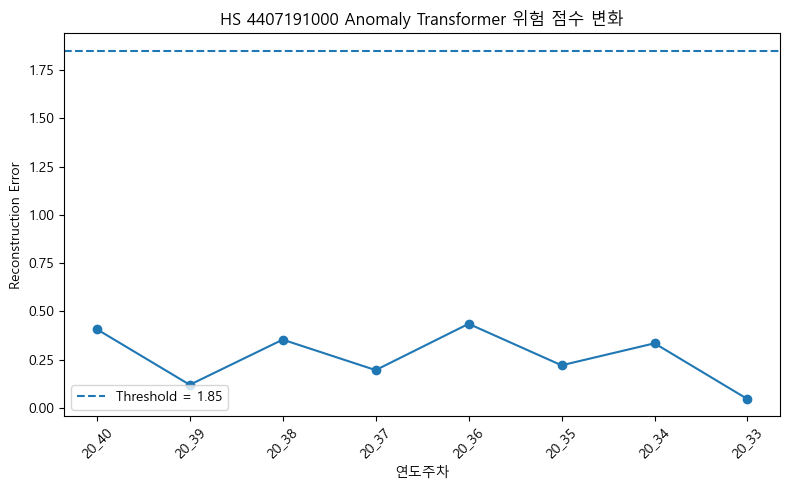

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_03 2.313 1187913.647
1    17_04 2.294 1589538.823
2    17_05 2.322 1797062.025
3    17_06 2.349 2135029.125
4    17_07 2.255 2589847.688
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]


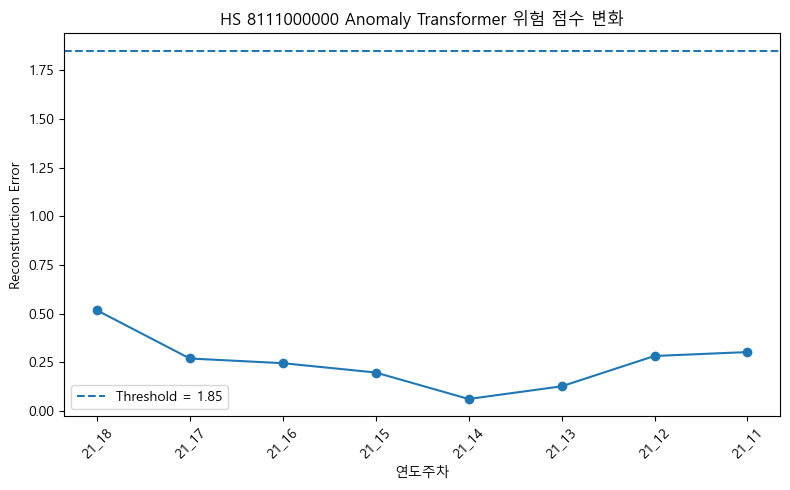

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_03 0.178 143718782.500
1    17_04 0.177 163414532.500
2    17_05 0.183 128339537.000
3    17_06 0.187  77542167.000
4    17_07 0.178  87019096.075
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]


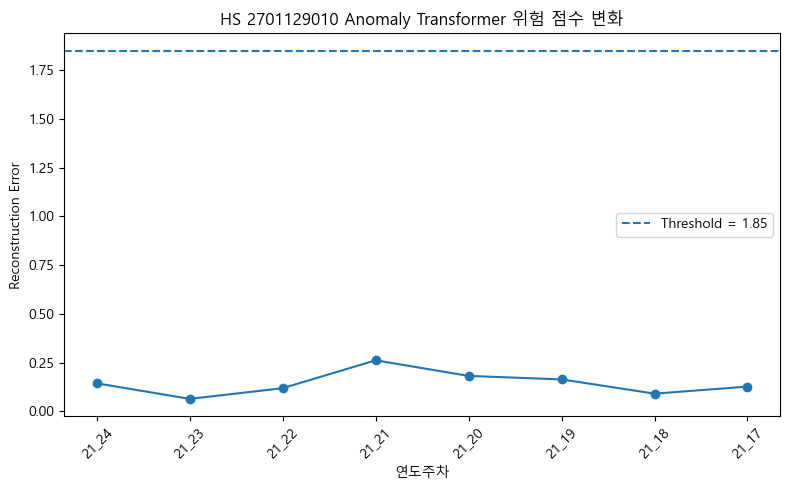

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_03 2.772 123365.050
1    17_04 2.811 160032.550
2    17_05 2.856 164322.550
3    17_06 2.862 142277.500
4    17_07 2.849 143690.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]


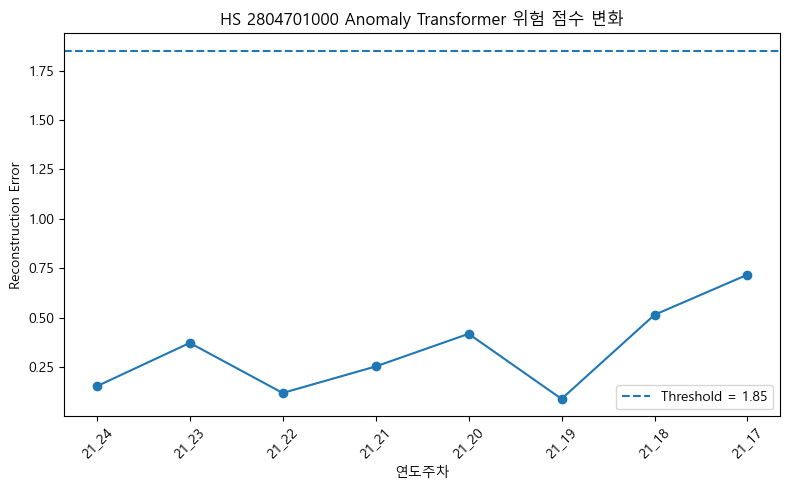

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_03 0.759  506508.750
1    17_04 0.735  936849.355
2    17_05 0.734  930738.055
3    17_06 0.754  893311.305
4    17_07 0.756 1637404.305
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]


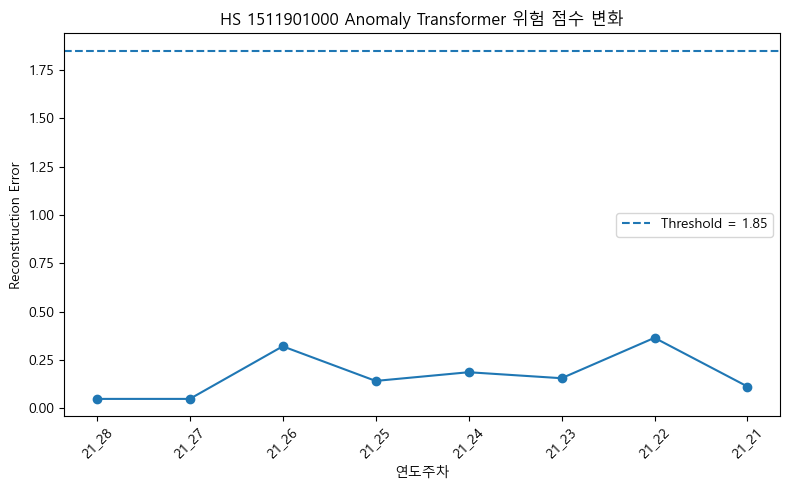

HS Code : 305531000
      연도주차     단가       신고중량
0    17_03 10.065  96064.000
1    17_04 10.143 112739.000
2    17_05 10.020 106671.250
3    17_06  9.953 107973.500
4    17_07  9.665  98612.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]


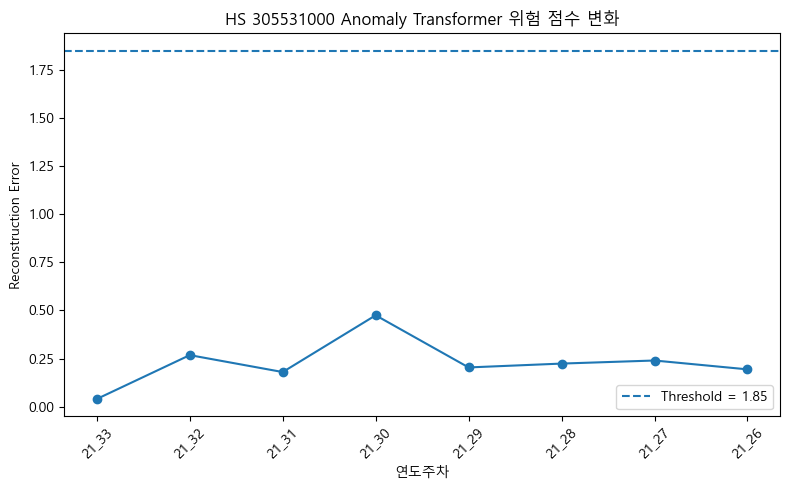

HS Code : 302140000
      연도주차     단가       신고중량
0    17_03 12.501 190731.825
1    17_04 12.297 248997.765
2    17_05 11.776 247770.110
3    17_06 11.204 258943.758
4    17_07 10.781 262438.498
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]


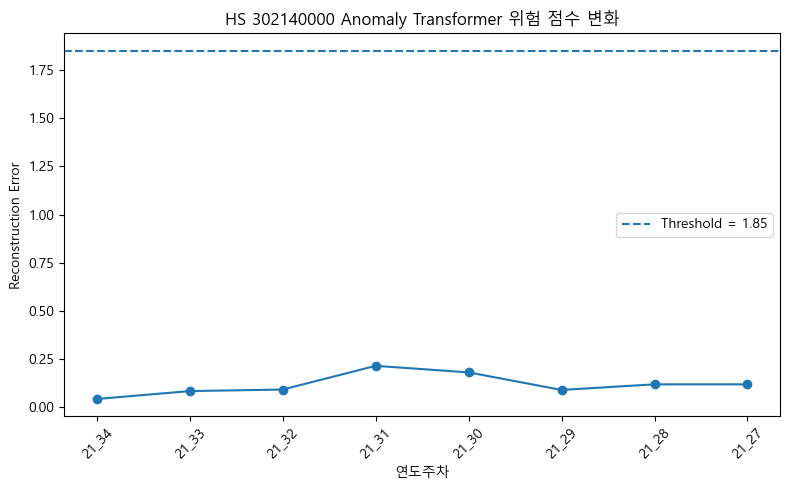

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_03 0.288 1533750.000
1    17_04 0.288 1533750.000
2    17_05 0.288 1533750.000
3    17_06 0.288 1533750.000
4    17_07 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]


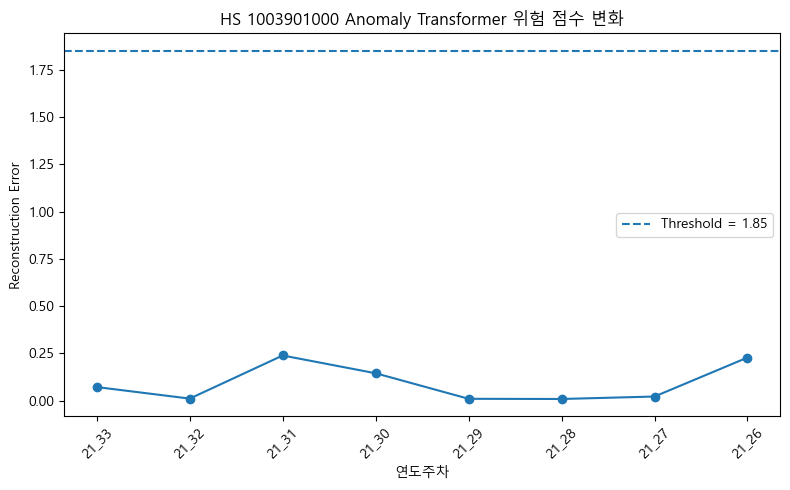

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_03 0.192 1642500.000
1    17_04 0.192 3149912.500
2    17_05 0.192 3412412.500
3    17_06 0.192 2054420.000
4    17_07 0.192 1861815.000
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]


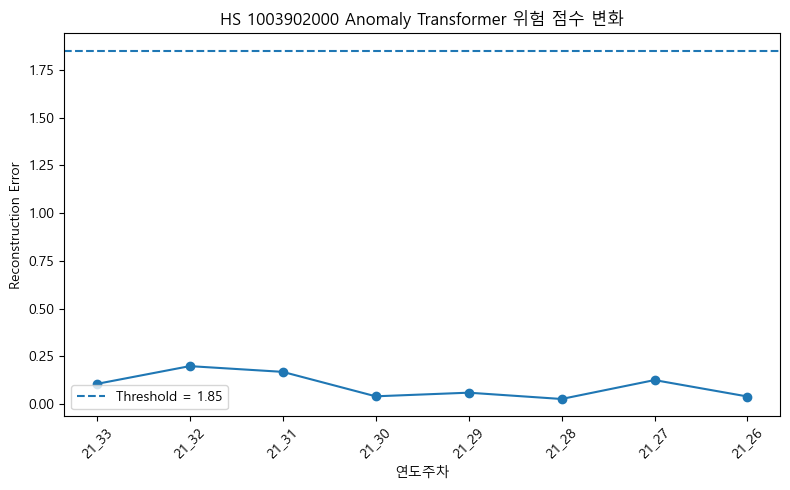

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_03 0.389  38475.125
1    17_04 0.389  38475.125
2    17_05 0.430 166375.125
3    17_06 0.477 415325.600
4    17_07 0.478 462700.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]


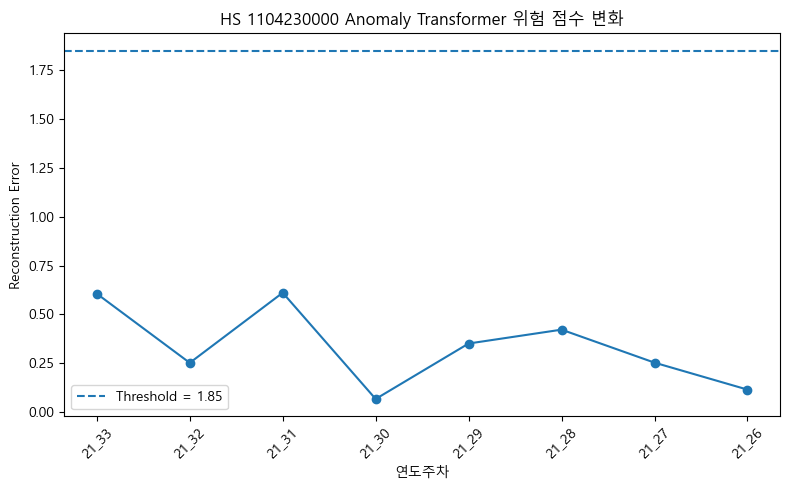

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_03 0.551  2149886.250
1    17_04 0.551  2149886.250
2    17_05 0.550  4114309.500
3    17_06 0.549  6381111.750
4    17_07 0.549  4234150.250
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]


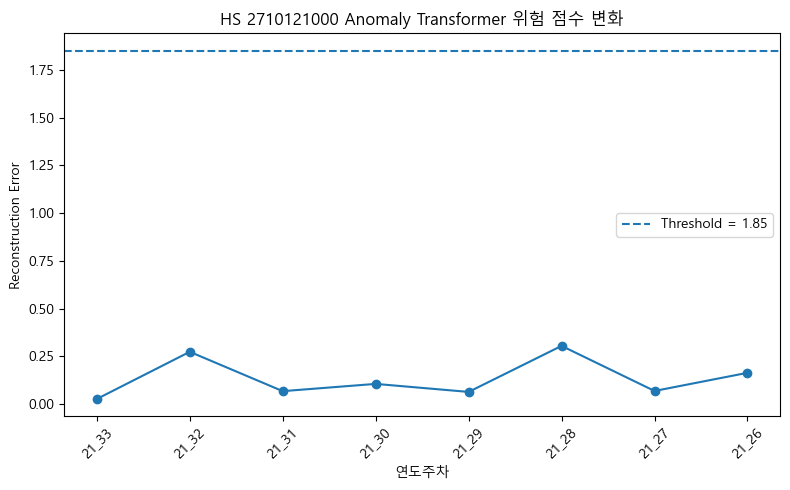

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_03 0.299 11374075.375
1    17_04 0.299 11374102.375
2    17_05 0.298 16317880.400
3    17_06 0.291 12415604.100
4    17_07 0.291 10819745.700
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]


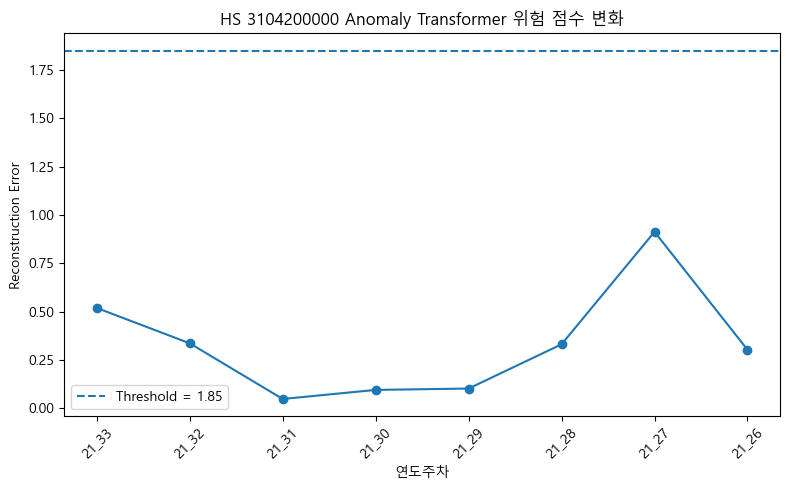

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_03 1.754  40702.550
1    17_04 1.801  49211.300
2    17_05 1.754  65983.925
3    17_06 1.838  79977.625
4    17_07 1.857  61760.131
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]


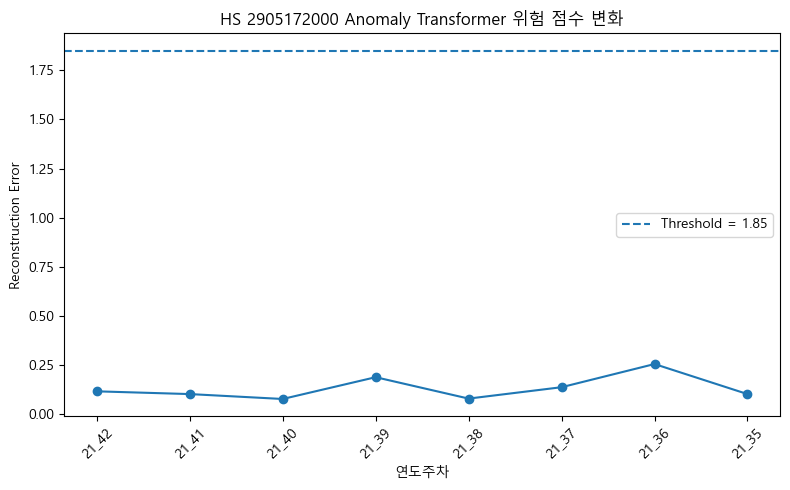

In [7]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
threshold = 1.85

# ==================================================
# 품목별 반복
# ==================================================
j = 0

for hs in 추출용:

    print(f'HS Code : {hs}')

    # 품목마다 e 초기화
    e = [0] * 8

    data = pd.DataFrame(columns=use_col)
    data = pd.concat([
        data,
        original[original['HS10단위부호'] == str(hs)]
    ])

    data = data.reset_index(drop=True)
    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)

    # ==================================================
    # 주차별 수입단가 및 신고중량 생성
    # ==================================================
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]

    df_price_week = (
        df_price
        .groupby('연도주차')[['과세가격미화금액', '신고중량']]
        .agg(['sum'])
        .reset_index()
    )

    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']

    # 수입이 없는 주차 생성
    df_price_week_hole = pd.DataFrame(columns=df_price_week.columns)

    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([
            df_price_week_hole,
            pd.DataFrame([{
                '연도주차': wk,
                '과세가격미화금액': 0,
                '신고중량': 0
            }])
        ], ignore_index=True)

    df_price_week_total = (
        pd.concat([df_price_week, df_price_week_hole])
        .sort_values('연도주차')
        .reset_index(drop=True)
    )

    # ==================================================
    # 직전 4주 평균
    # ==================================================
    price_w4 = []
    kg_w4 = []

    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(
            df_price_week_total[['과세가격미화금액']]
            .iloc[x:x + 4]
            .mean()
            .iloc[0]
        )

        kg_w4.append(
            df_price_week_total[['신고중량']]
            .iloc[x:x + 4]
            .mean()
            .iloc[0]
        )

    df_price_4w = df_price_week_total.iloc[3:].copy()

    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4

    df_price_4w = df_price_4w.reset_index(drop=True)

    df_price_4w['과세가격미화금액'] = (
        df_price_4w['과세가격미화금액']
        .replace(0, np.nan)
        .ffill()
    )

    df_price_4w['신고중량'] = (
        df_price_4w['신고중량']
        .replace(0, np.nan)
        .ffill()
    )

    df_price_4w['단가'] = (
        df_price_4w['과세가격미화금액'] /
        df_price_4w['신고중량']
    )

    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    df_price_4w = df_price_4w.replace([np.inf, -np.inf], np.nan)
    df_price_4w[['단가', '신고중량']] = df_price_4w[['단가', '신고중량']].ffill().bfill()

    print(df_price_4w)

    # ==================================================
    # 학습 데이터 생성
    # ==================================================
    train_data = df_price_4w[['단가', '신고중량']].values.astype(np.float32)

    train_data = np.nan_to_num(
        train_data,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # 표준화
    scaler = StandardScaler()
    train_data_scaled = scaler.fit_transform(train_data)

    # 8주 window 생성
    train_windows = make_windows(train_data_scaled, window_size=8)

    if len(train_windows) == 0:
        print(f"{hs} 품목은 학습 가능한 window가 부족합니다.")
        j += 1
        continue

    # ==================================================
    # Anomaly Transformer 모델 생성 및 학습
    # ==================================================
    
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = AnomalyTransformer(
        input_dim=2,
        d_model=128,
        num_heads=8,
        sigma=1.0
    )

    model = train_anomaly_transformer(
        model,
        train_windows,
        epochs=100,
        lr=0.001,
        lambda_dis=0.01
    )

    model.eval()

    # ==================================================
    # 학습된 모델로 최근 8개 구간 reconstruction error 계산
    # ==================================================
    for l in range(b[j] - 8, b[j]):

        segment = df_price_4w.iloc[
            p_eriod - l - 8 : p_eriod - l
        ][['단가', '신고중량']].values.astype(np.float32)

        if segment.shape[0] < 8:
            continue

        segment = np.nan_to_num(
            segment,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # 학습 때 사용한 scaler를 그대로 적용
        segment_scaled = scaler.transform(segment)

        input_tensor = torch.tensor(
            segment_scaled,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            output_tensor, _ = model(input_tensor)

        recon_error = (
            ((output_tensor - input_tensor) ** 2)
            .sum(dim=-1)
            .sqrt()
            .detach()
            .numpy()
        )

        last_error = recon_error[0, -1]

        e[l - b[j] + 8] = round(float(last_error), 3)

        if last_error > threshold:
            k[j] += 1

        if z[j] < last_error:
            z[j] = round(float(last_error), 3)
            c[j] = l

    # ==================================================
    # 위험경보 여부
    # ==================================================
    if z[j] > threshold:
        o[j] = 1

    # ==================================================
    # 그래프
    # ==================================================
    plt.rc('font', family='Malgun Gothic')
    plt.rc('axes', unicode_minus=False)

    x_labels = [
        df_price_4w['연도주차'].iloc[-1 - l]
        for l in range(b[j] - 8, b[j])
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(x_labels, e, marker='o')
    plt.axhline(y=threshold, linestyle='--', label=f'Threshold = {threshold}')
    plt.xticks(rotation=45)
    plt.xlabel("연도주차")
    plt.ylabel("Reconstruction Error")
    plt.title(f"HS {hs} Anomaly Transformer 위험 점수 변화")
    plt.legend()
    plt.tight_layout()
    plt.show()

    j += 1

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model29(1)'] = o
collect.loc[50, 'Model29(1)'] = np.sum(o)
collect.loc[:49, 'Model29(2)'] = z
collect.loc[50, 'Model29(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[30]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[30]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[30]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)